# Catalogue des figures de quantification (Sprint 42)

Galerie commentée des **17 figures** générées par la bibliothèque `src/figures/` (catalogues `quantization/{pedagogy,pipeline,impact}`). Chaque figure est accompagnée d'un **paragraphe FR prêt à copier** dans une slide ou un chapitre de manuscrit.

Ce notebook **n'implémente aucune figure** : il appelle les *builders* via le registre (S4201) et affiche les PNG produits. Pour régénérer les figures, exécuter §0 puis relancer le notebook — figures **et** valeurs affichées se mettent à jour sans édition manuelle.

Référence textuelle unique : [`docs/context/quantization_strategies.md`](../../../docs/context/quantization_strategies.md) (S4202). En cas de doublon, ce doc fait foi.

## §0 — Reproduction

Une seule cellule (re)génère les 3 catalogues via le registre. Les figures sont écrites sous `docs/figures/quantization/`.

In [1]:
import sys
from pathlib import Path

# Racine du dépôt : remonter jusqu'à pyproject.toml (robuste sous nbconvert)
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from IPython.display import Image, Markdown, display

import src.figures.catalogs  # noqa: F401 — auto-enregistrement des catalogues
from src.figures import registry
from src.figures.style import DEFAULT_OUT_ROOT, apply_style
from src.utils.reproducibility import set_seed

set_seed(42)
apply_style('slide')
FIG = DEFAULT_OUT_ROOT  # docs/figures/

print('Catalogues enregistrés :', registry.list_catalogs())
produced = []
for name in ['quantization/pedagogy', 'quantization/pipeline', 'quantization/impact']:
    produced += registry.get_catalog(name)(DEFAULT_OUT_ROOT)
print(f'{len(produced)} figures (re)générées.')

✅ Seed fixé à 42
Catalogues enregistrés : ['quantization/impact', 'quantization/pedagogy', 'quantization/pipeline']


[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quantization/pedagogy/mapping_affine_int8.png


[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quantization/pedagogy/grilles_int8_vs_q15.png
[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quantization/pedagogy/qat_vs_ptq.png


[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quantization/pedagogy/erreur_quantification_poids.png


[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quantization/pedagogy/dynamique_sigma_inv.png
[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quantization/pedagogy/fakequant_forward.png


...

[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quantization/pipeline/pipeline_int8_ptq_board.png
[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quantization/pipeline/pipeline_int8_v2_q15.png


[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quantization/pipeline/pipeline_comparatif.png
[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quantization/impact/metrique_par_strategie.png


[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quantization/impact/ablation_perte_f1.png


[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quantization/impact/recuperation_q15_maha.png
[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quantization/impact/ram_gap3.png


[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quantization/impact/paradoxe_latence.png
[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quantization/impact/qat_vs_ptq_resultats.png
17 figures (re)générées.


## §1 — Panorama : les 3 artefacts « slide unique »

Tableau comparatif synthétique (reformaté depuis [`quantization_strategies.md`](../../../docs/context/quantization_strategies.md)) :

| Stratégie | Format poids | Moment | Calibration scale | RAM | Latence M4 | Métrique |
|-----------|-------------|--------|-------------------|-----|-----------|----------|
| **FP32** | float32 | — | — | ×1 | référence | référence |
| **INT8 QAT (PC)** | int8 | pendant l'entraînement | apprise (STE) | ÷4 | (PC) | préservée (Δ≤0.006) |
| **INT8 PTQ legacy (board)** | int8 | après, au boot | figée 1/128 | ÷4 | ≥ FP32 | effondrée (F1 0.07–0.15) |
| **INT8 v2 calibré** | int8 | après (émulé/board) | per-tensor/-channel | ÷4 | ≥ FP32 | récupérée (≈ FP32) |
| **Q15** | int16 | après | per-tensor /32767 | ÷2 | ≥ FP32 | recouvrée (grande dynamique) |
| **HDC int16-AM** | int16 | — | — | ×2.33 | — | Δ=0 |

Les deux figures de synthèse à mettre en tête d'un jeu de slides :

**F5 — pipeline comparatif** (où chaque stratégie applique la quantification) :

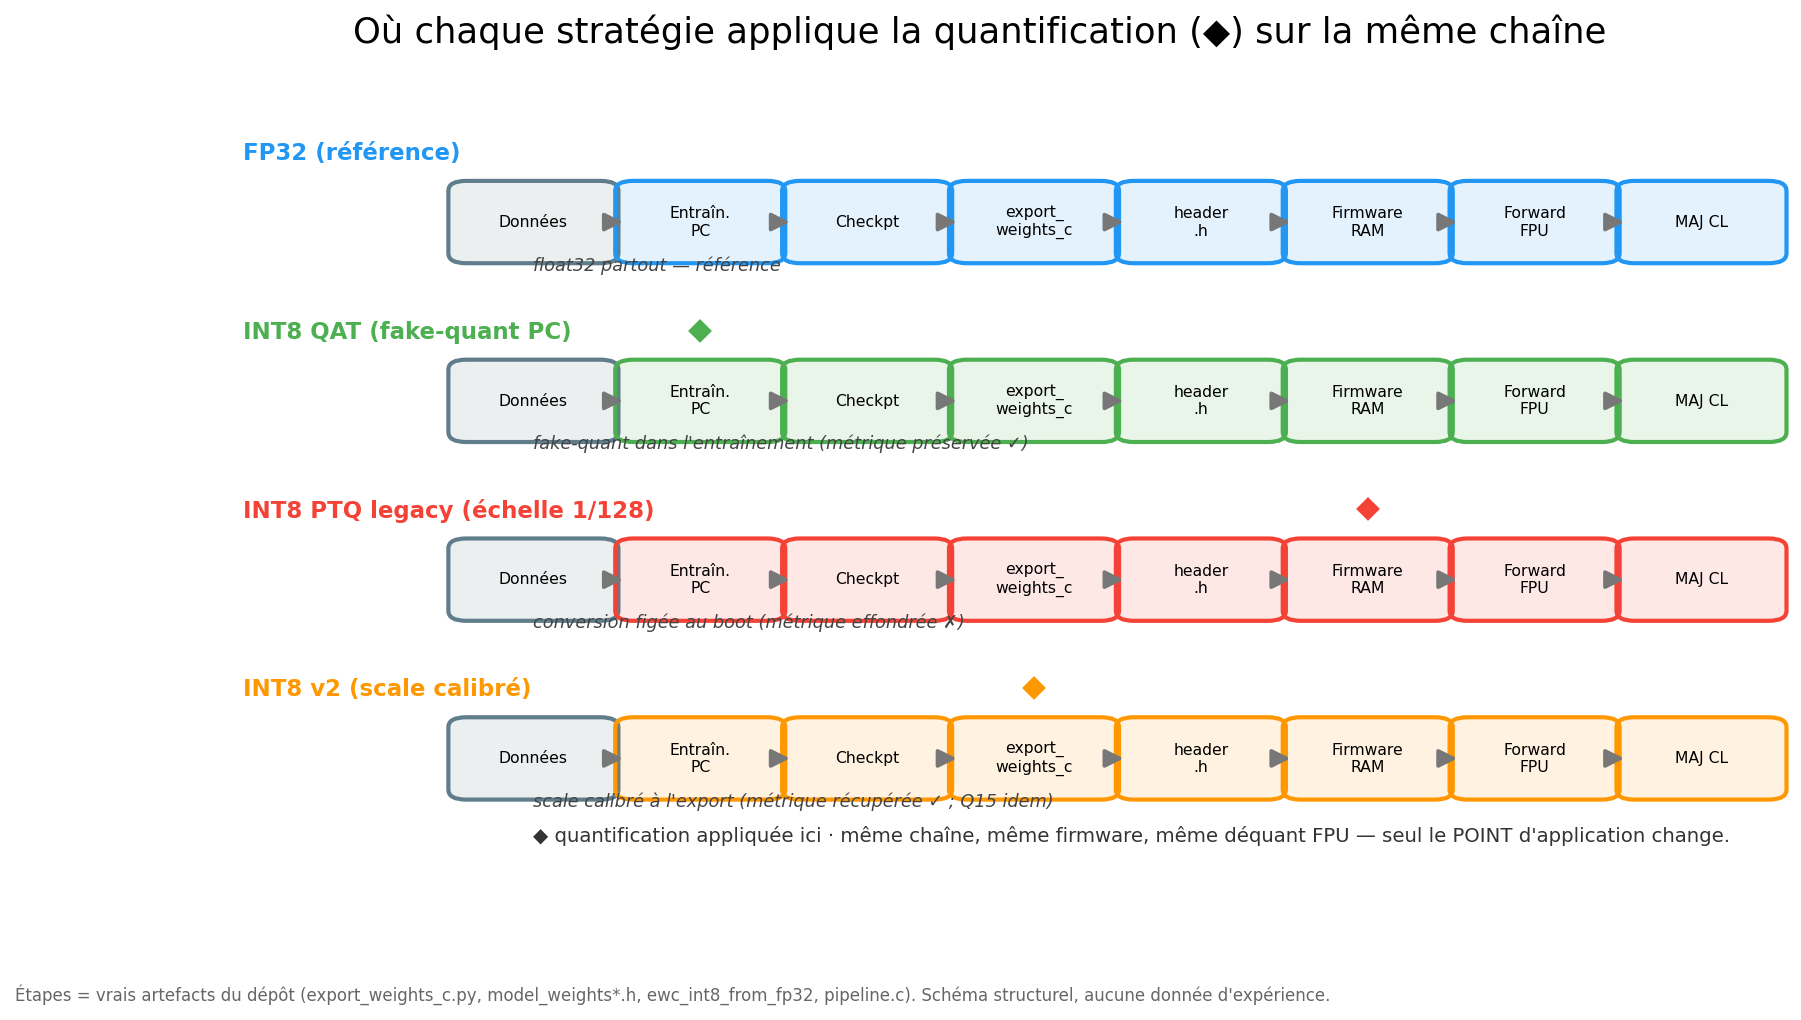

In [2]:
display(Image(str(FIG / "quantization/pipeline" / "pipeline_comparatif.png")))

**I1 — Δmétrique par stratégie** (« quantifier ≠ quantifier ») :

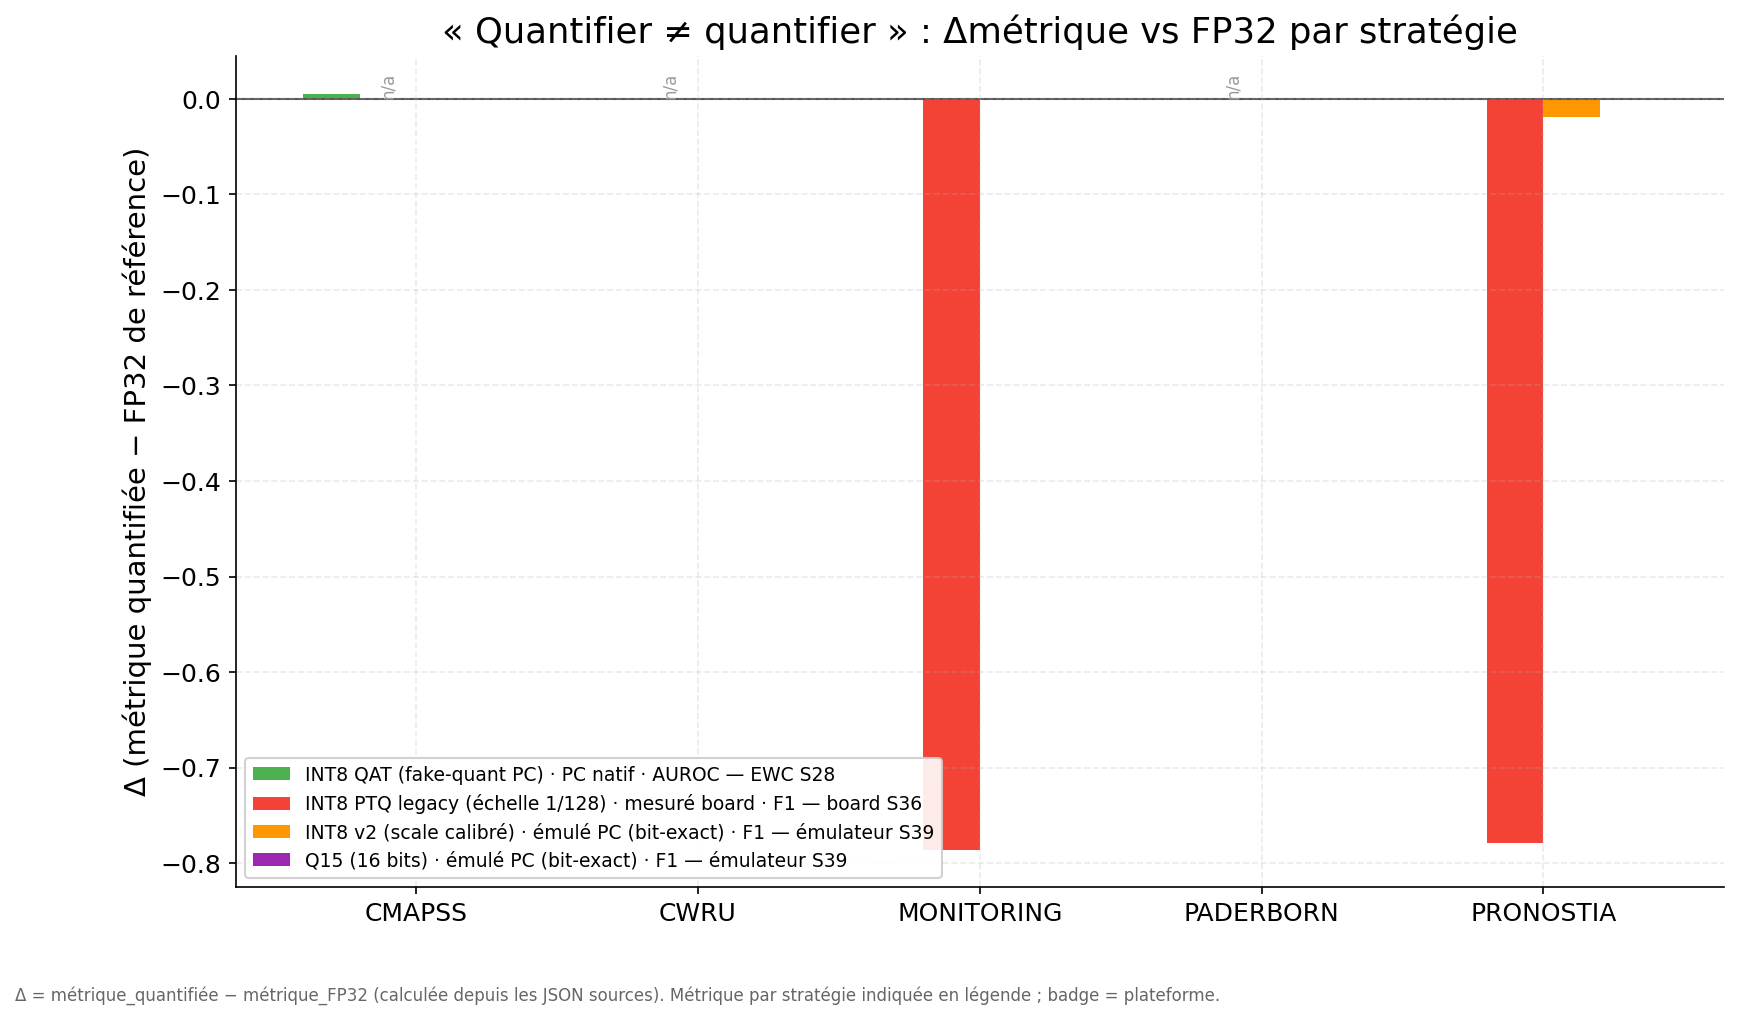

In [3]:
display(Image(str(FIG / "quantization/impact" / "metrique_par_strategie.png")))

> **À dire à l'oral** : le format stocké (int8) est *le même* pour QAT, PTQ legacy et v2 ; ce qui change le résultat, c'est **le moment** (pendant vs après l'entraînement) et **la calibration de l'échelle**. C'est le message central du chapitre quantification.

## §2 — Mécanismes : ce que la quantification fait aux données (P1–P6)

Figures conceptuelles sur **de vrais tenseurs** du projet (poids EWC, Σ⁻¹ Mahalanobis), quantifiés via l'émulateur bit-exact `int8_c_emulation.py`.

### P1 — Mapping affine FP32→INT8

**Ce que montre la figure** : 256 niveaux régulièrement espacés (pas *s*) recouvrent l'axe continu ; au-delà de ±127·*s* les poids sont **saturés** (clamp).

**Phrase-clé (oral)** : *« INT8 = une règle graduée : 256 crans, un pas fixe, et tout ce qui dépasse est rabattu au bord. »*

**Piège de lecture** : Piège : avec l'échelle legacy figée 1/128, des poids réels tombent dans la zone de clamp — d'où la perte.

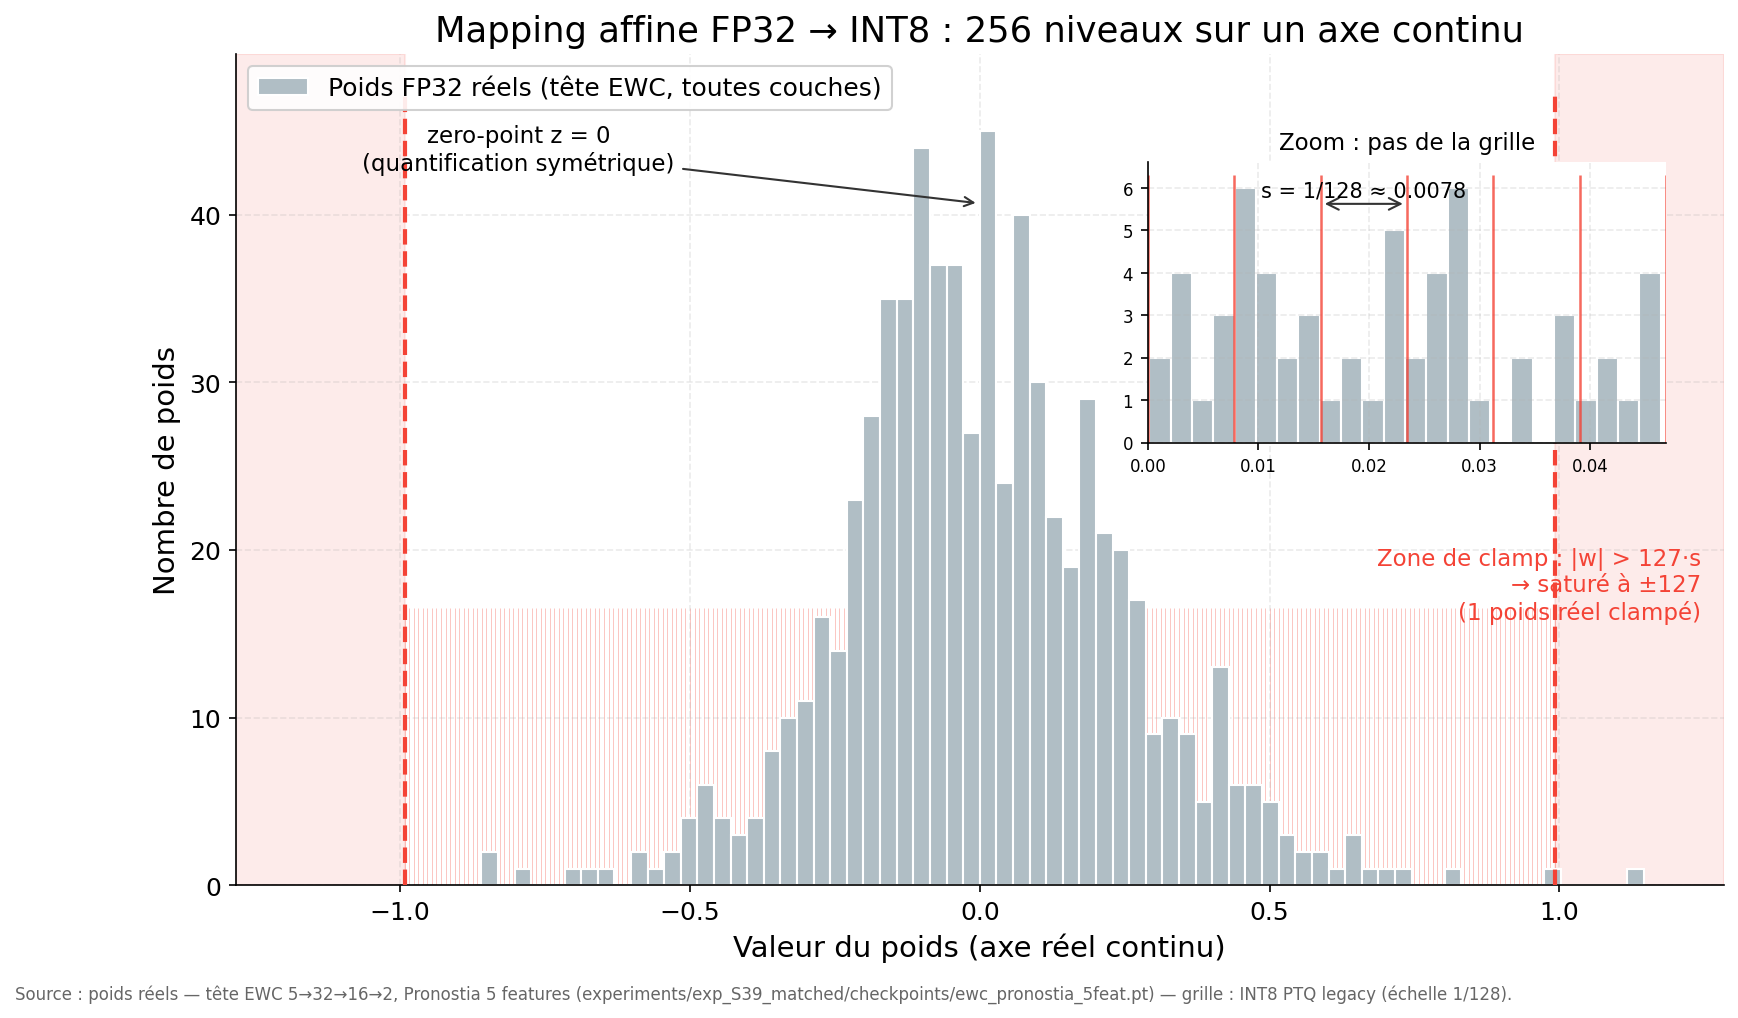

In [4]:
display(Image(str(FIG / "quantization/pedagogy" / "mapping_affine_int8.png")))

### P2 — Grilles INT8 (256) vs Q15 (65 536)

**Ce que montre la figure** : Sur la dynamique réelle de Σ⁻¹, la grille INT8 écrase les petites valeurs à 0 ; Q15 les conserve.

**Phrase-clé (oral)** : *« Même intervalle, mais Q15 a 256× plus de crans : les petits coefficients survivent. »*

**Piège de lecture** : Piège : ne pas lire l'écart en nombre de niveaux mais en **pas près de zéro**.

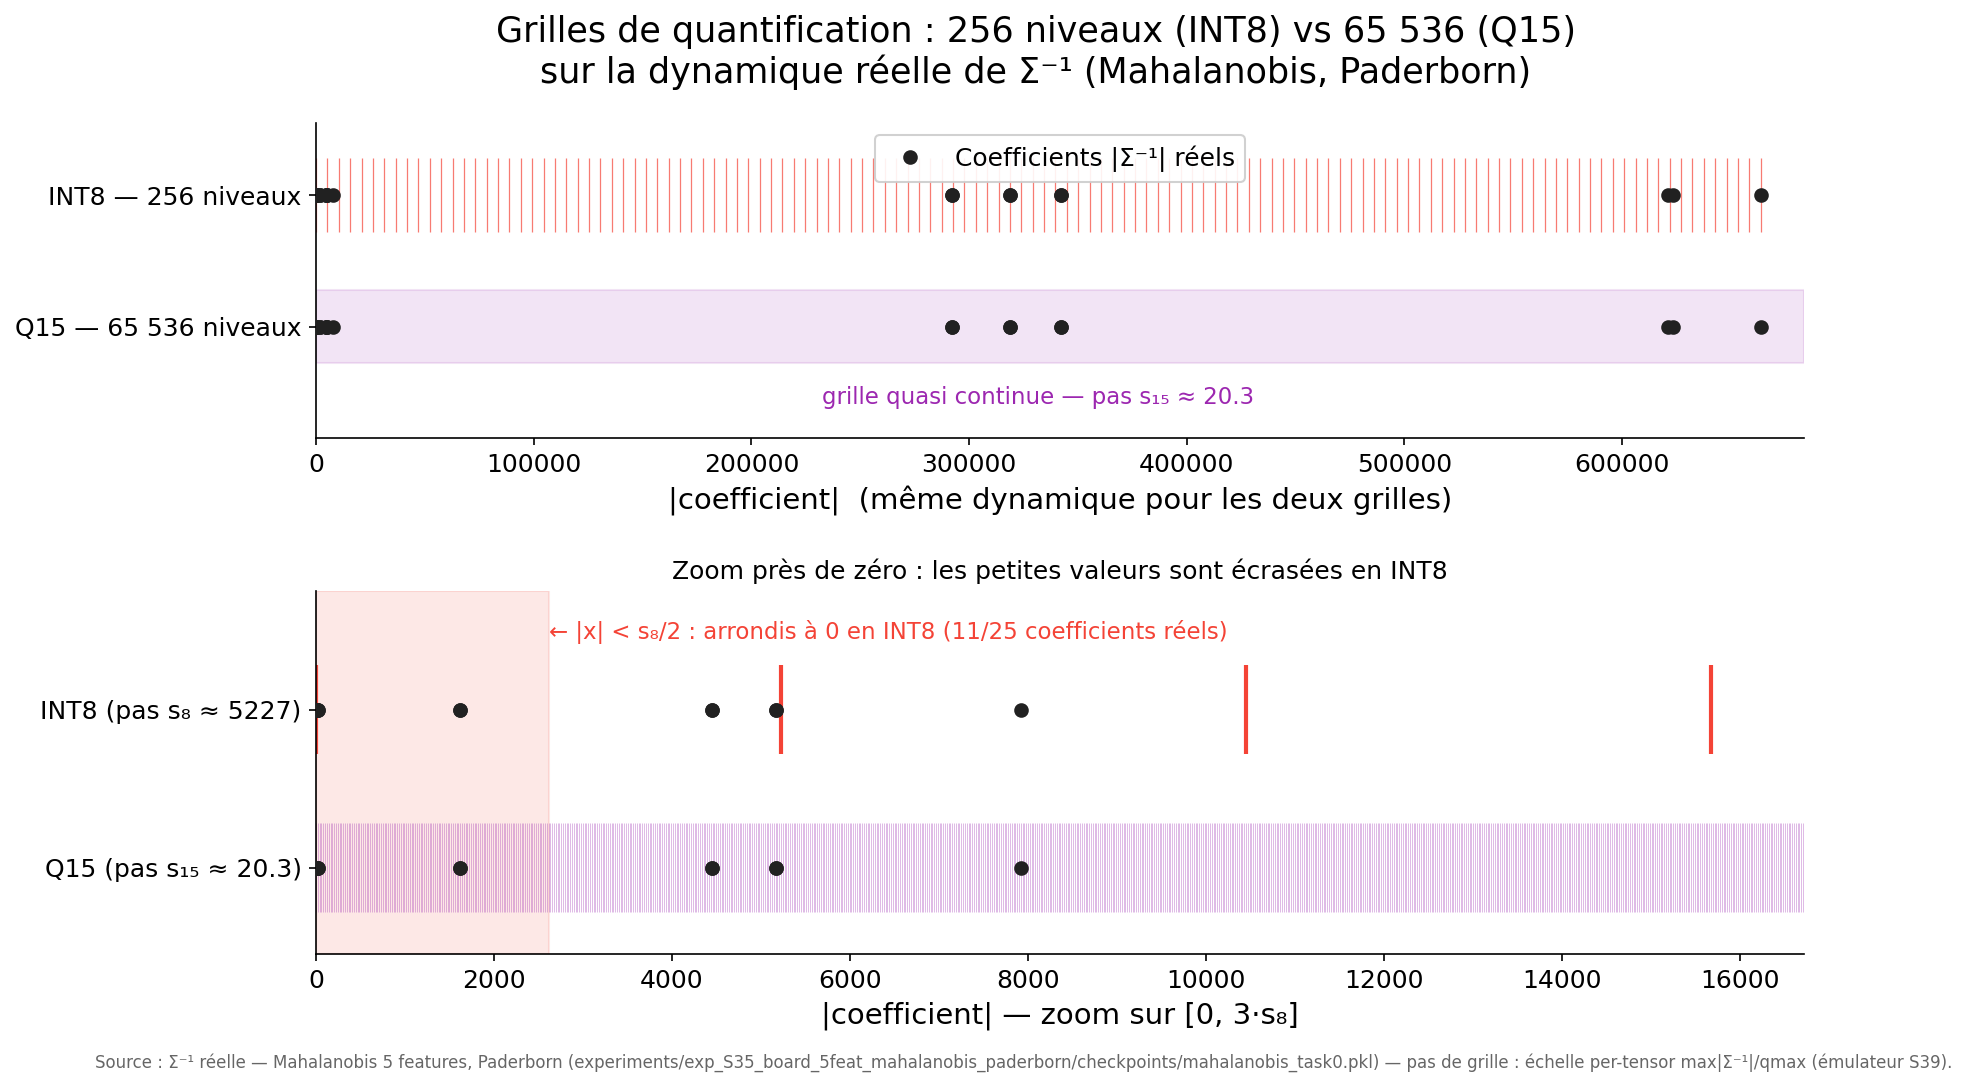

In [5]:
display(Image(str(FIG / "quantization/pedagogy" / "grilles_int8_vs_q15.png")))

### P3 — QAT vs PTQ (schéma)

**Ce que montre la figure** : QAT insère le fake-quant dans l'entraînement (le gradient voit l'erreur, STE) ; PTQ convertit après coup.

**Phrase-clé (oral)** : *« QAT : le modèle s'entraîne *avec* l'erreur de quantification ; PTQ : il la découvre au déploiement. »*

**Piège de lecture** : Illustration (schéma de principe, pas de données).

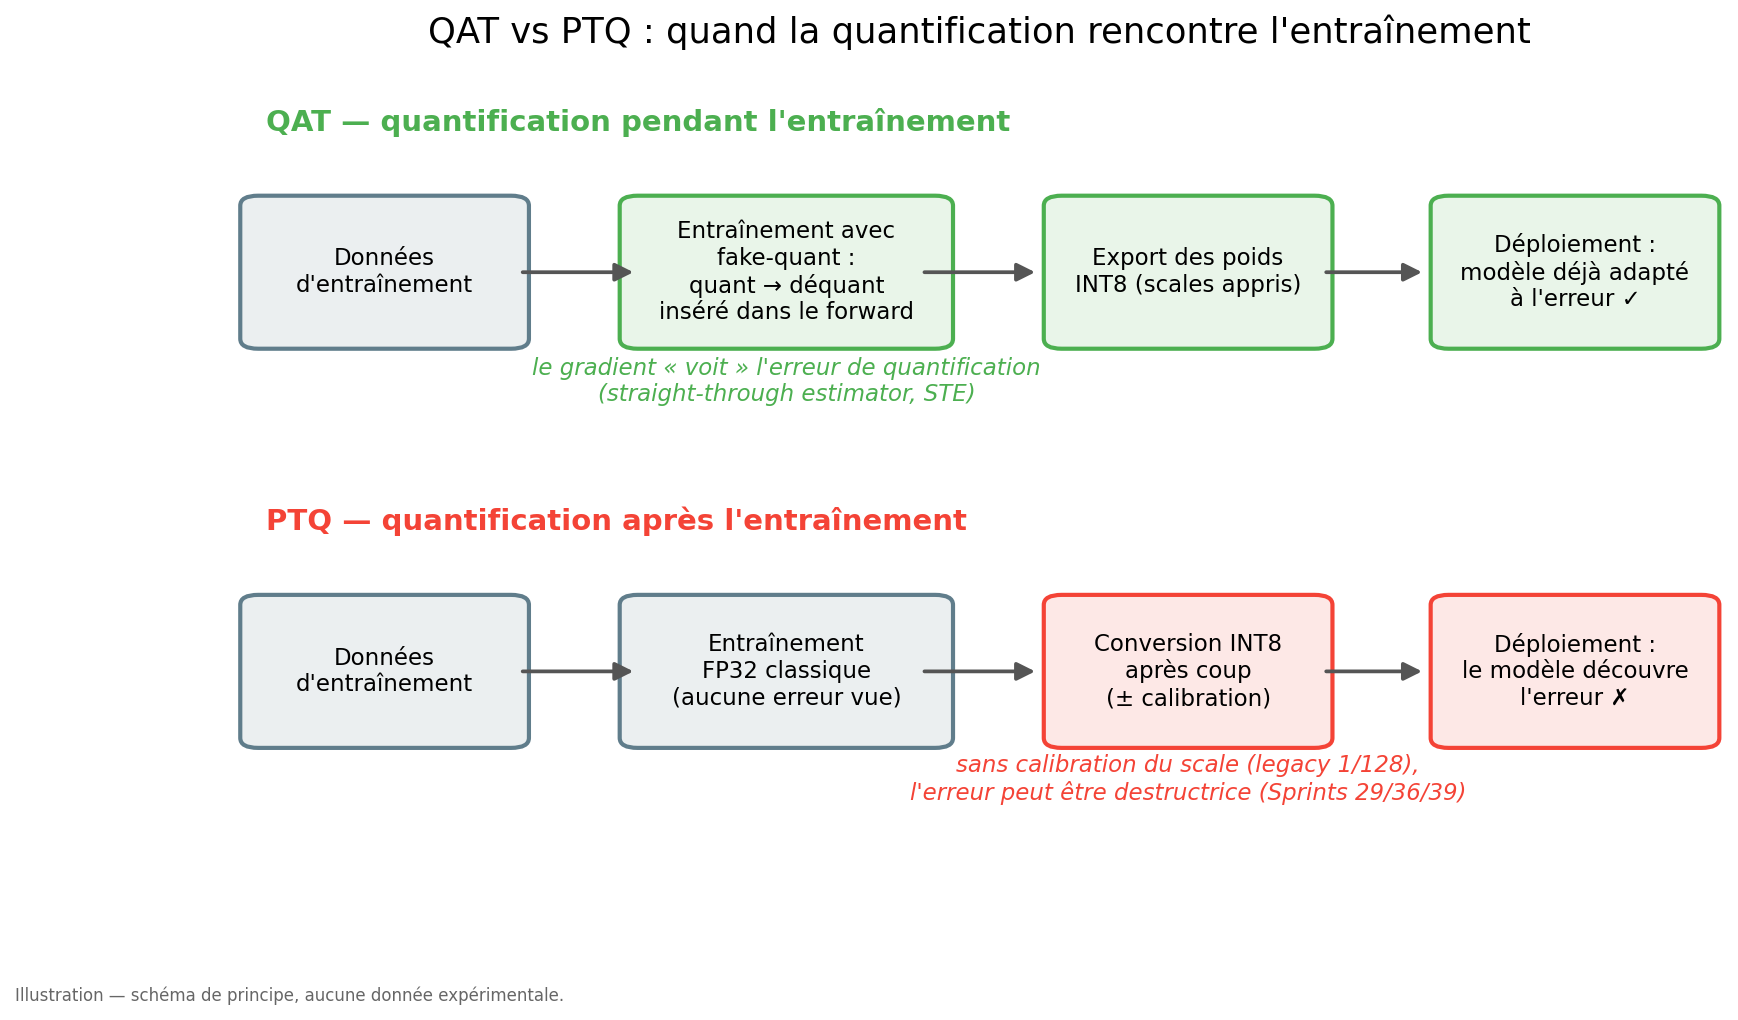

In [6]:
display(Image(str(FIG / "quantization/pedagogy" / "qat_vs_ptq.png")))

### P4 — Erreur de quantification sur poids EWC réels

**Ce que montre la figure** : Distribution de |w − déquant(quant(w))| : legacy ≫ per-channel calibré ≫ Q15.

**Phrase-clé (oral)** : *« L'erreur n'est pas une constante : elle dépend du schéma — trois ordres de grandeur d'écart. »*

**Piège de lecture** : Piège : la longue queue du legacy = clamp des poids hors ±127/128.

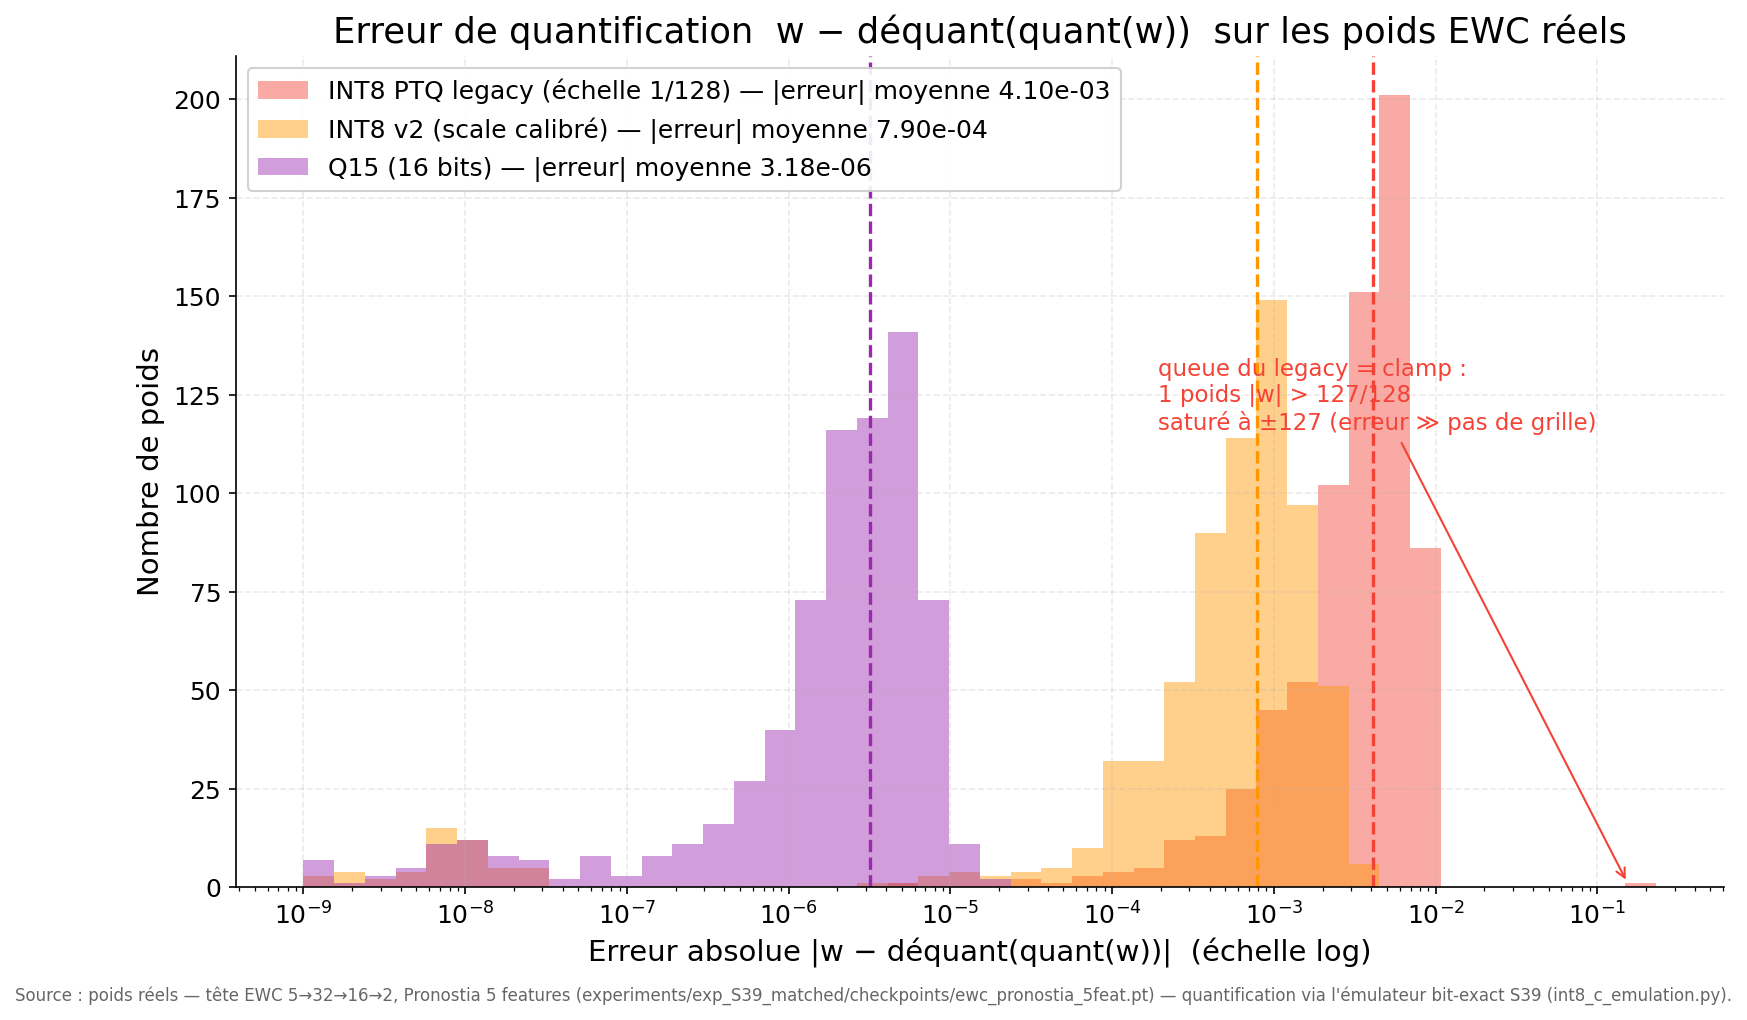

In [7]:
display(Image(str(FIG / "quantization/pedagogy" / "erreur_quantification_poids.png")))

### P5 — Grande dynamique de Σ⁻¹

**Ce que montre la figure** : Coefficients triés par magnitude vs premiers niveaux INT8/Q15 : une fraction tombe sous *s₈/2* et collapse à 0 en INT8.

**Phrase-clé (oral)** : *« Quand un tenseur couvre 5–6 ordres de grandeur, INT8 n'a pas la résolution ; Q15 oui. »*

**Piège de lecture** : Lien : explique la dégradation Mahalanobis INT8 (Sprint 34).

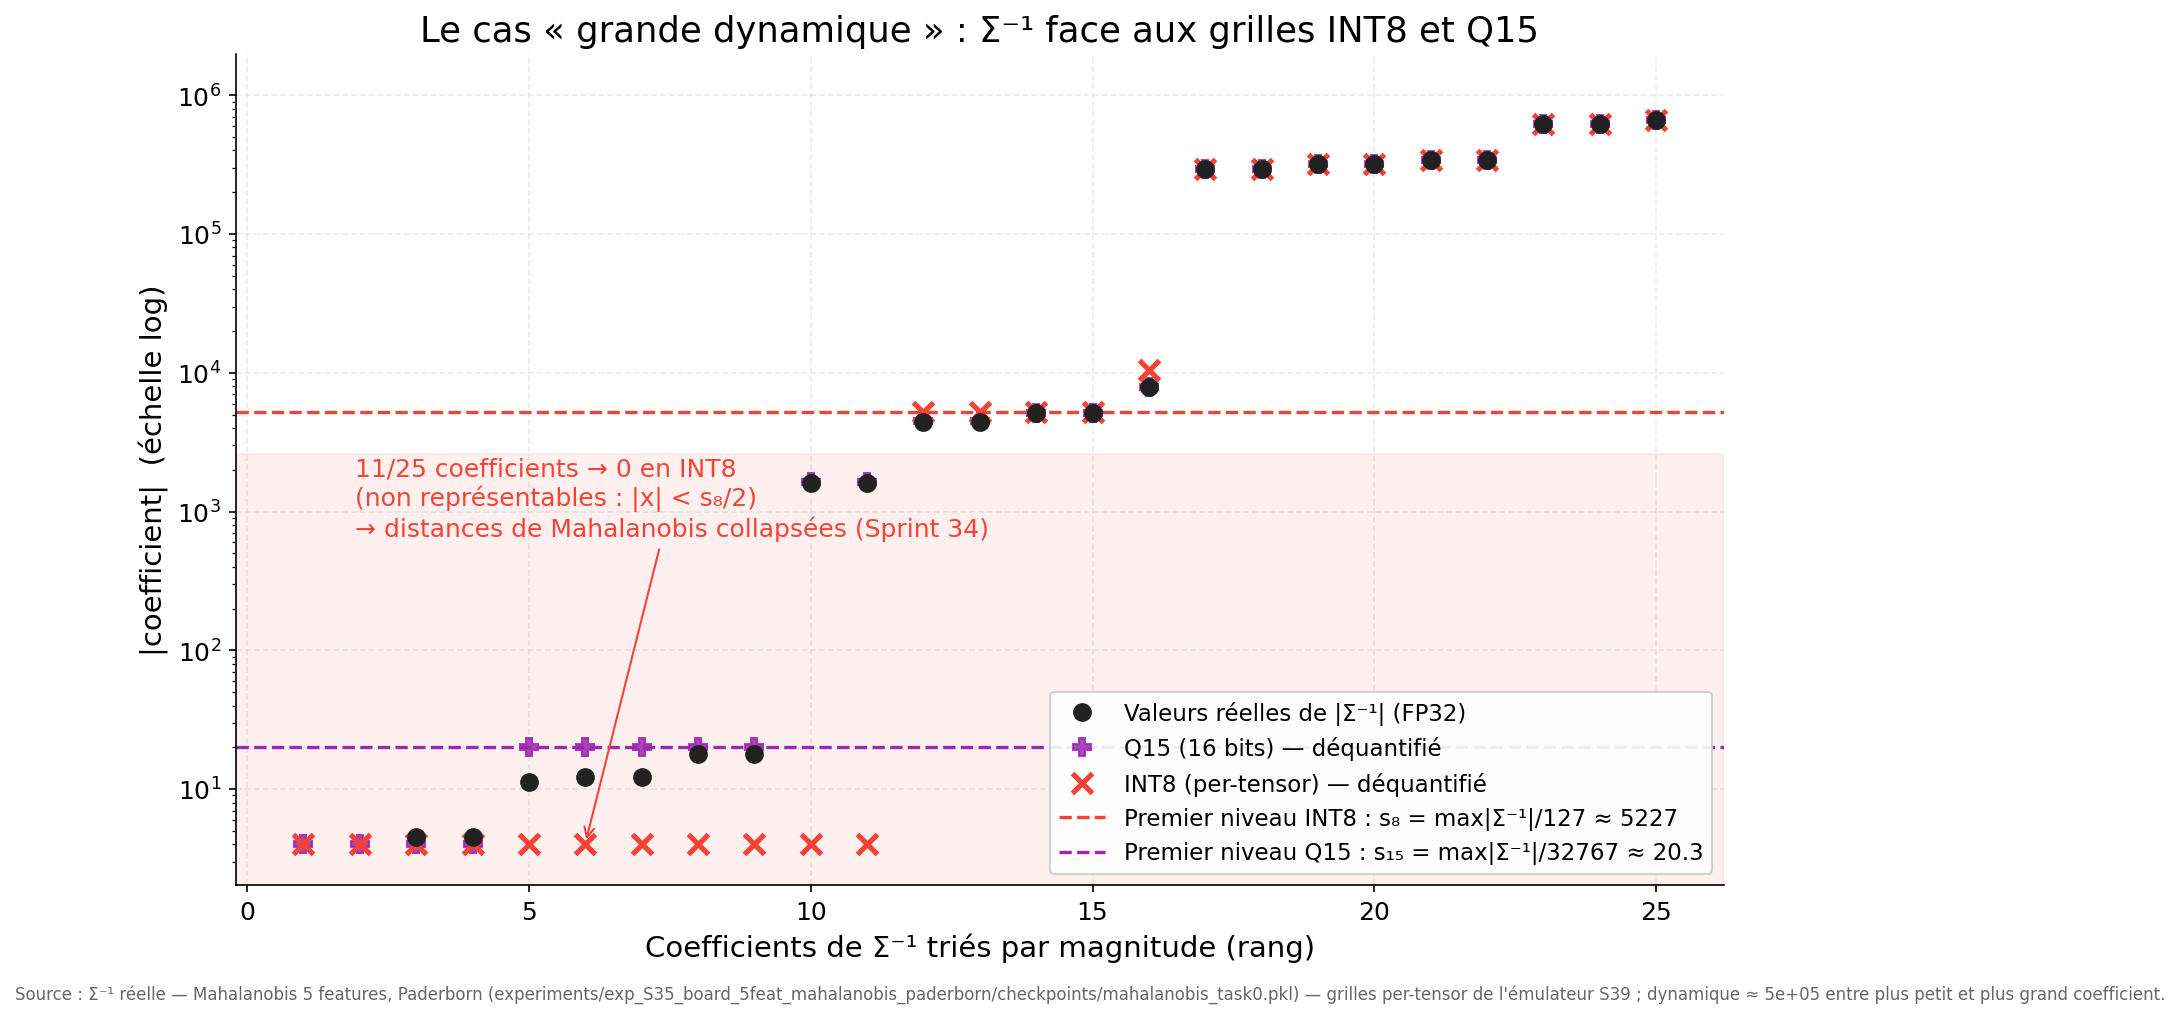

In [8]:
display(Image(str(FIG / "quantization/pedagogy" / "dynamique_sigma_inv.png")))

### P6 — Trois forwards d'un neurone (schéma)

**Ce que montre la figure** : FP32 / fake-quant QAT (float) / firmware INT8 (MAC entier puis déquant FPU).

**Phrase-clé (oral)** : *« Sur la board, les poids sont int8 mais le calcul repasse en float sur la FPU : d'où le paradoxe latence. »*

**Piège de lecture** : Illustration (schéma de principe).

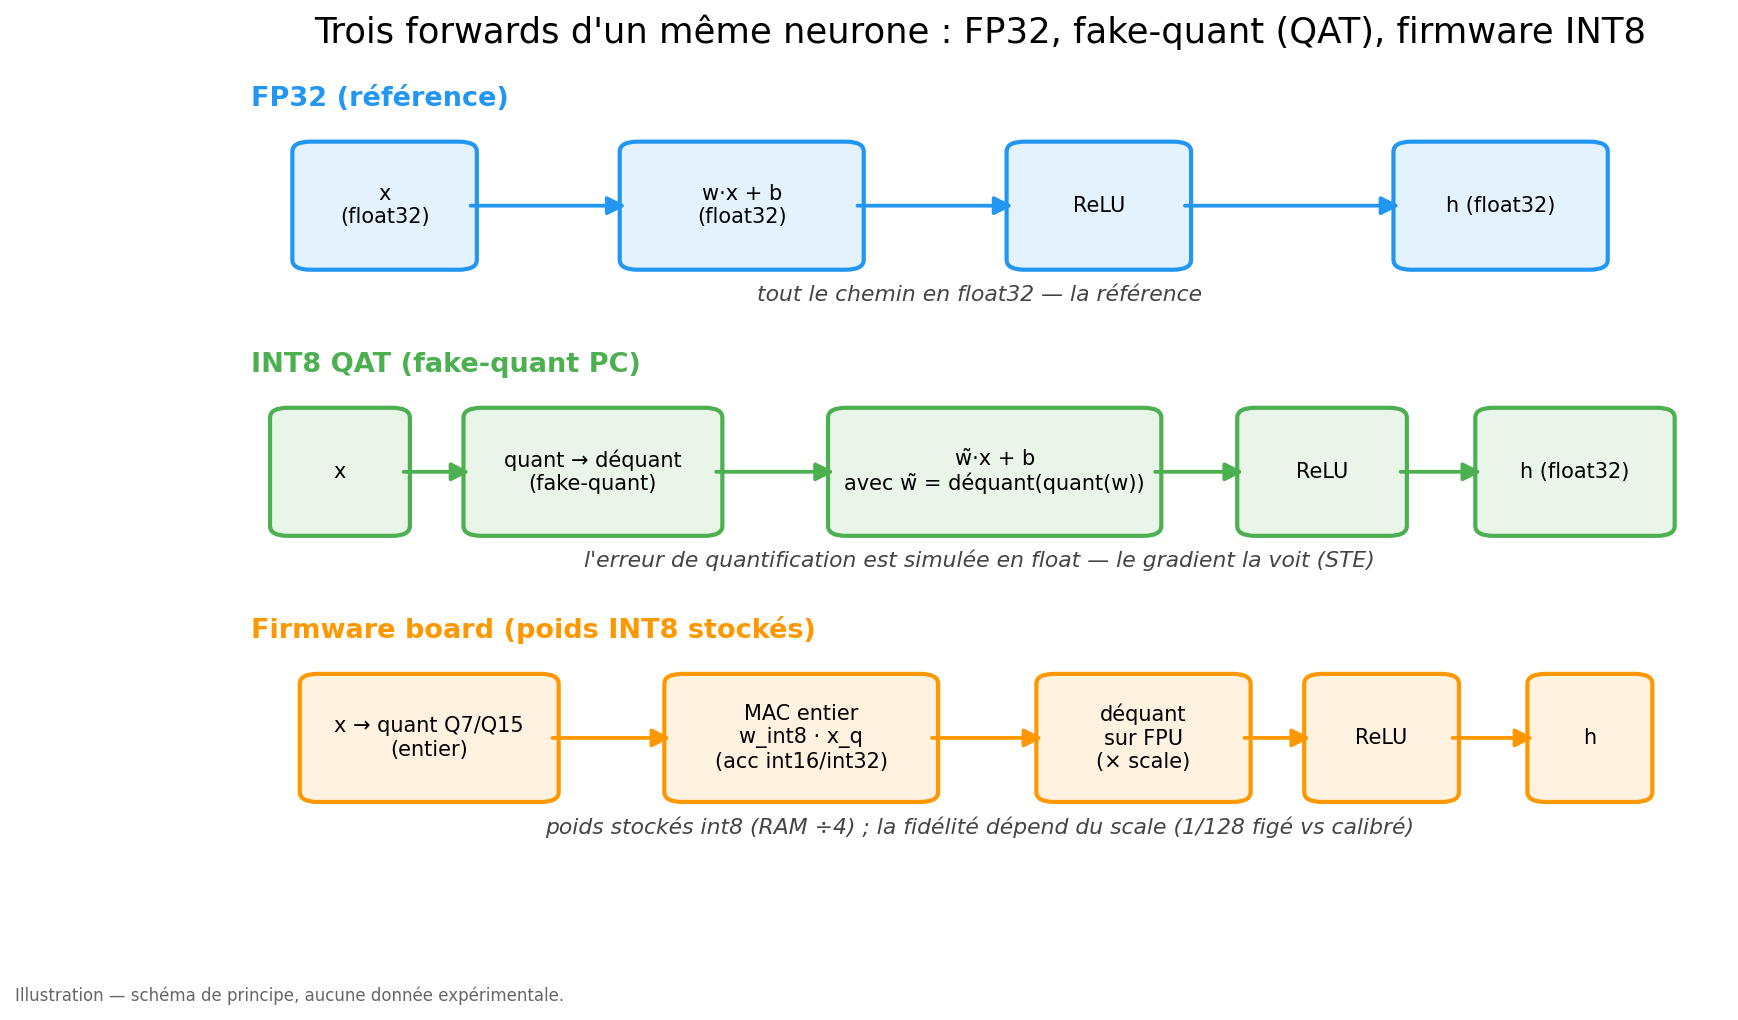

In [9]:
display(Image(str(FIG / "quantization/pedagogy" / "fakequant_forward.png")))

## §3 — Où dans la chaîne : F1→F4

Chaîne réelle du dépôt : `données → entraînement PC → checkpoint → export_weights_c.py → header .h → firmware (RAM) → forward (FPU) → MAJ CL`. Chaque figure marque (◆) le point où la quantification s'applique.

> **Pourquoi QAT et PTQ divergent alors que le format est identique** : les deux produisent des poids int8 stockés à l'identique. Mais **QAT applique la quantification dans la boucle d'entraînement** (F2) — le modèle s'adapte à l'erreur — tandis que **PTQ legacy l'applique une seule fois au boot du firmware** (F3) avec une échelle figée, sur un modèle qui n'a jamais vu cette erreur. La correction (F4) déplace le point d'application vers **l'export, avec un scale calibré sur les données** : même firmware, même déquant FPU, mais métrique récupérée.

### F1 — Chaîne de référence FP32

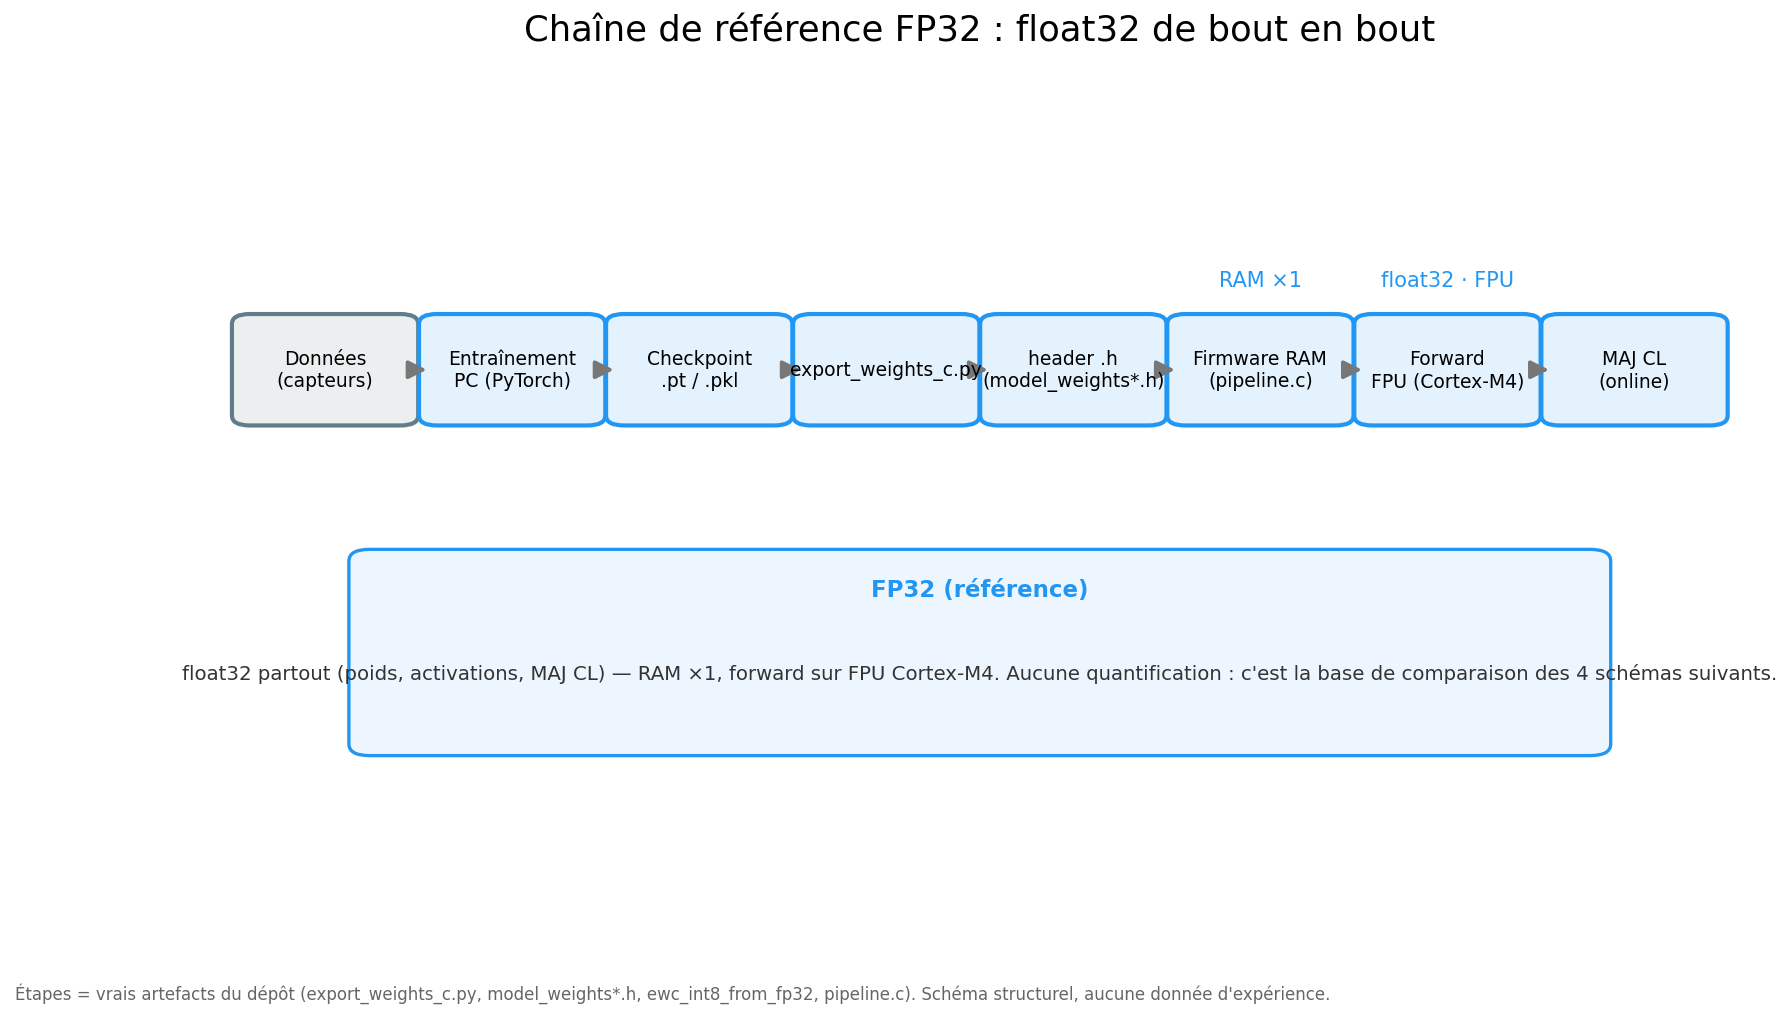

In [10]:
display(Image(str(FIG / "quantization/pipeline" / "pipeline_fp32.png")))

### F2 — INT8 QAT (fake-quant dans l'entraînement)

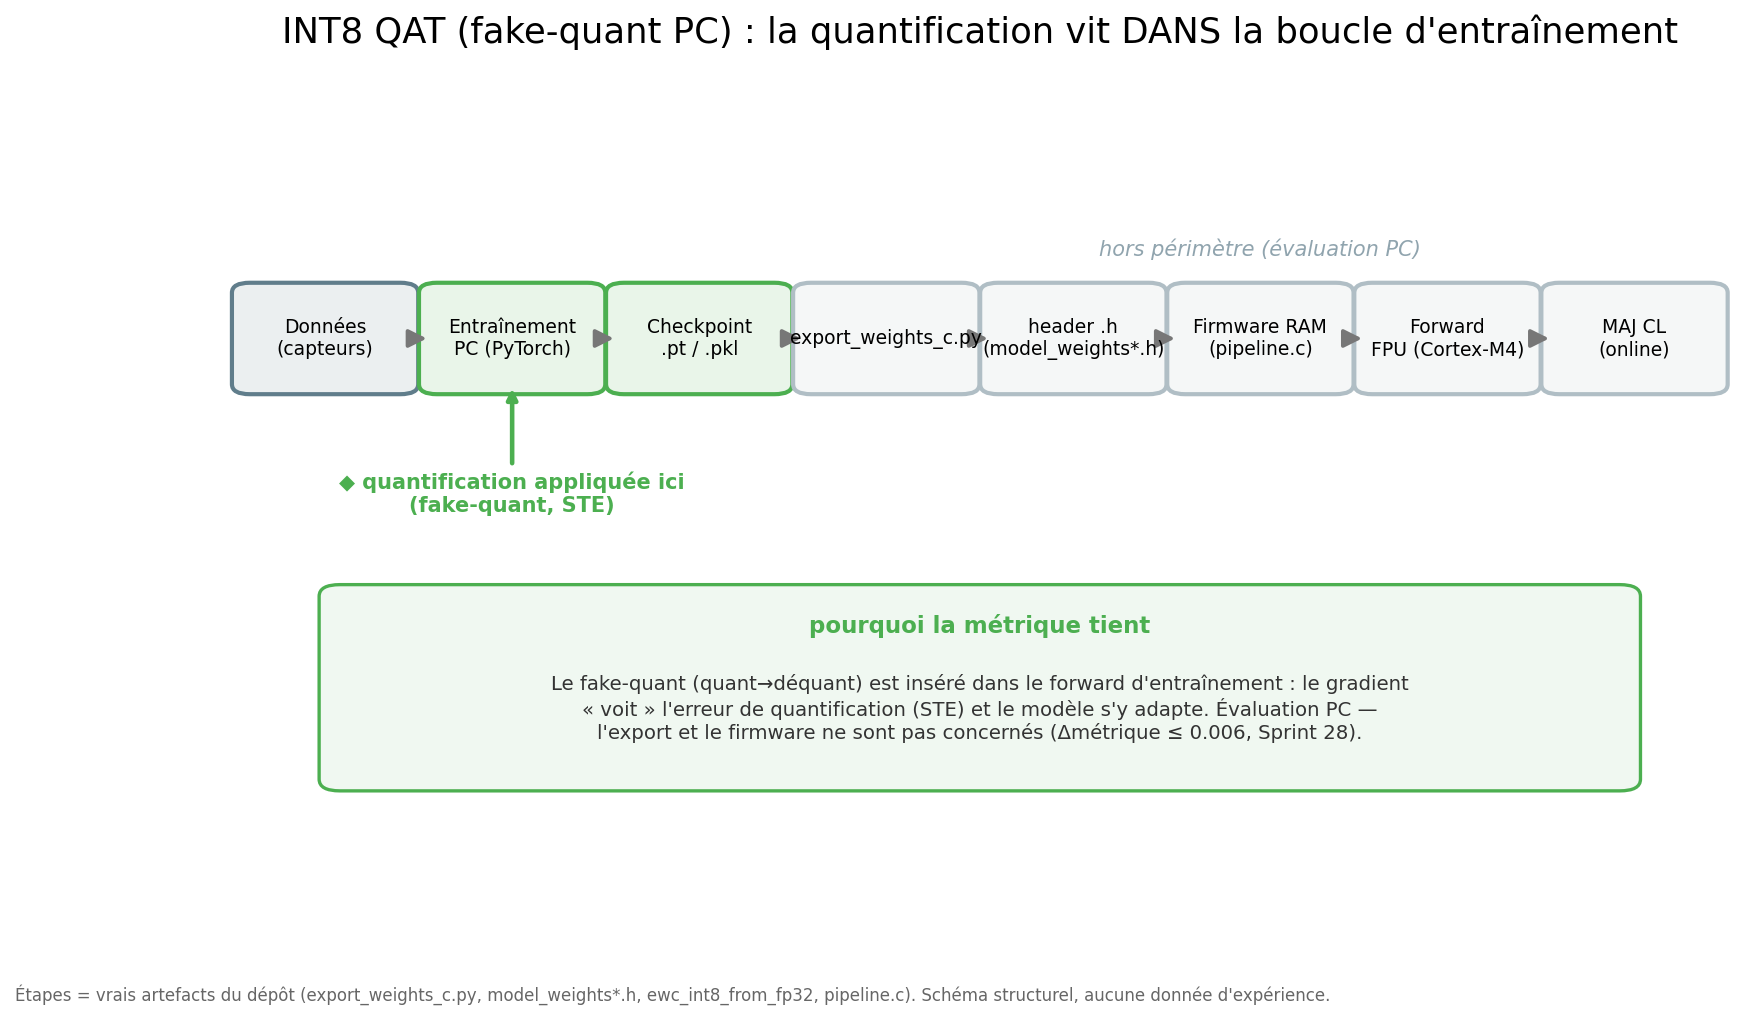

In [11]:
display(Image(str(FIG / "quantization/pipeline" / "pipeline_int8_qat_pc.png")))

### F3 — INT8 PTQ legacy (one-shot au boot)

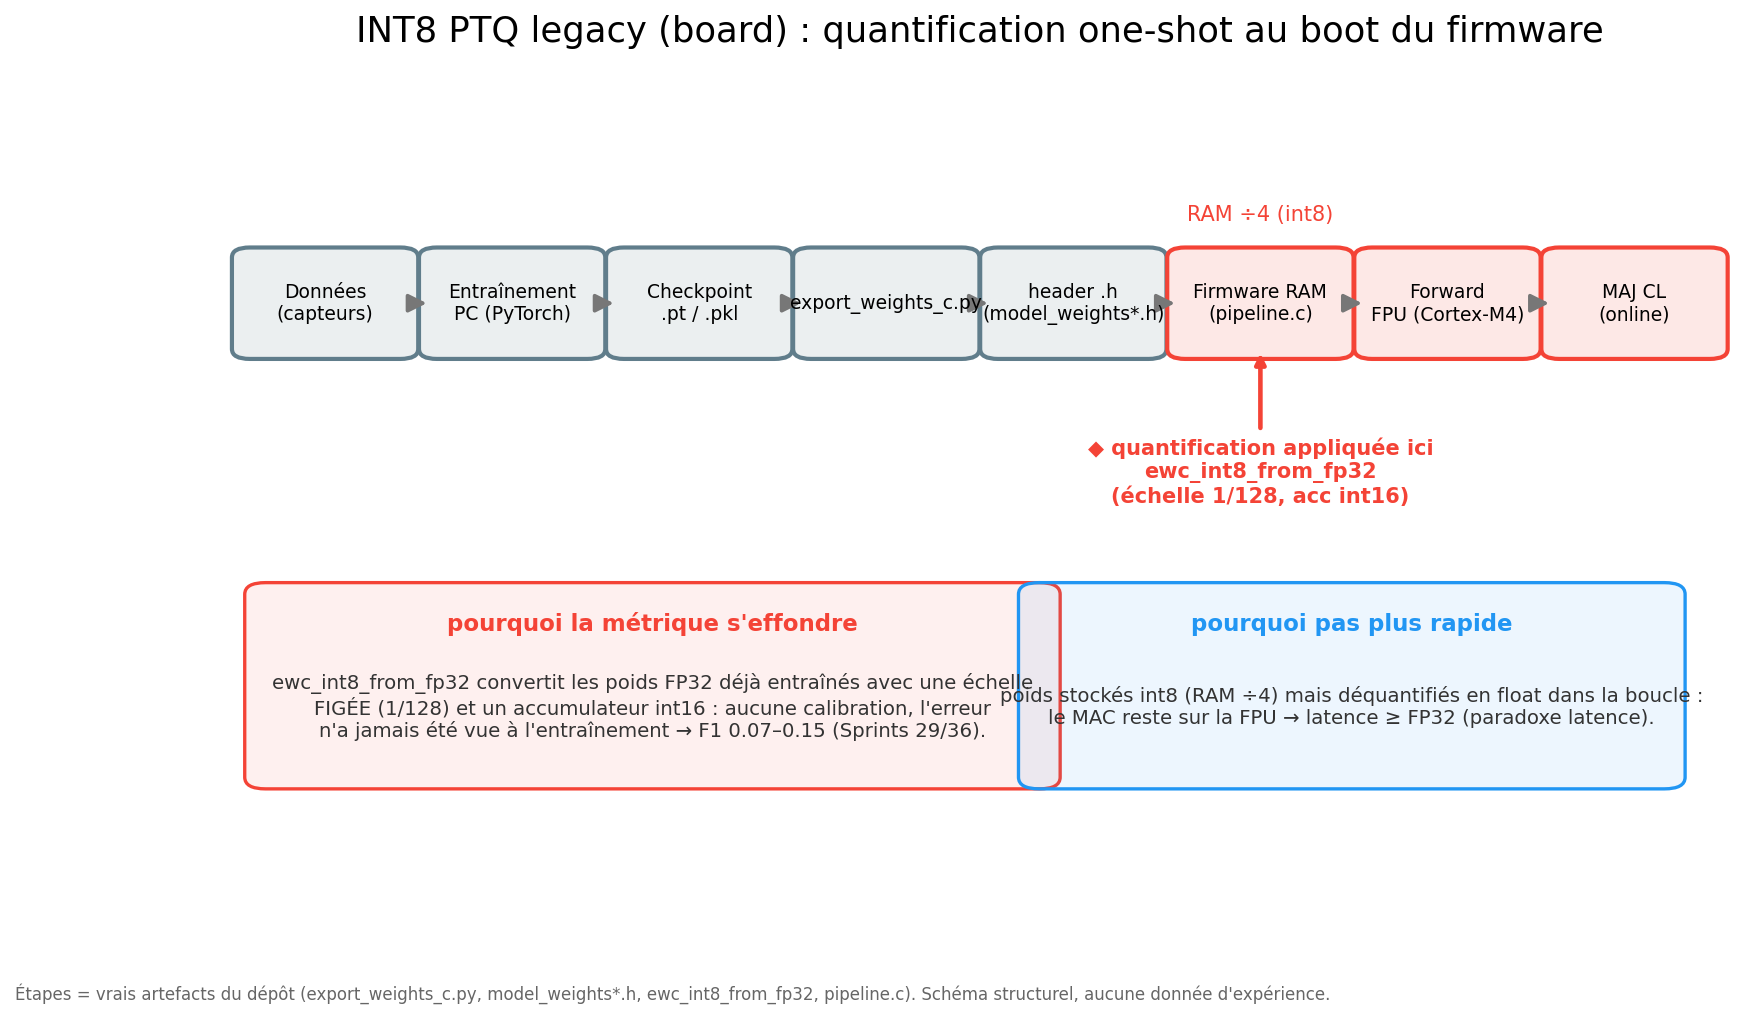

In [12]:
display(Image(str(FIG / "quantization/pipeline" / "pipeline_int8_ptq_board.png")))

### F4 — INT8 v2 / Q15 (scale calibré à l'export)

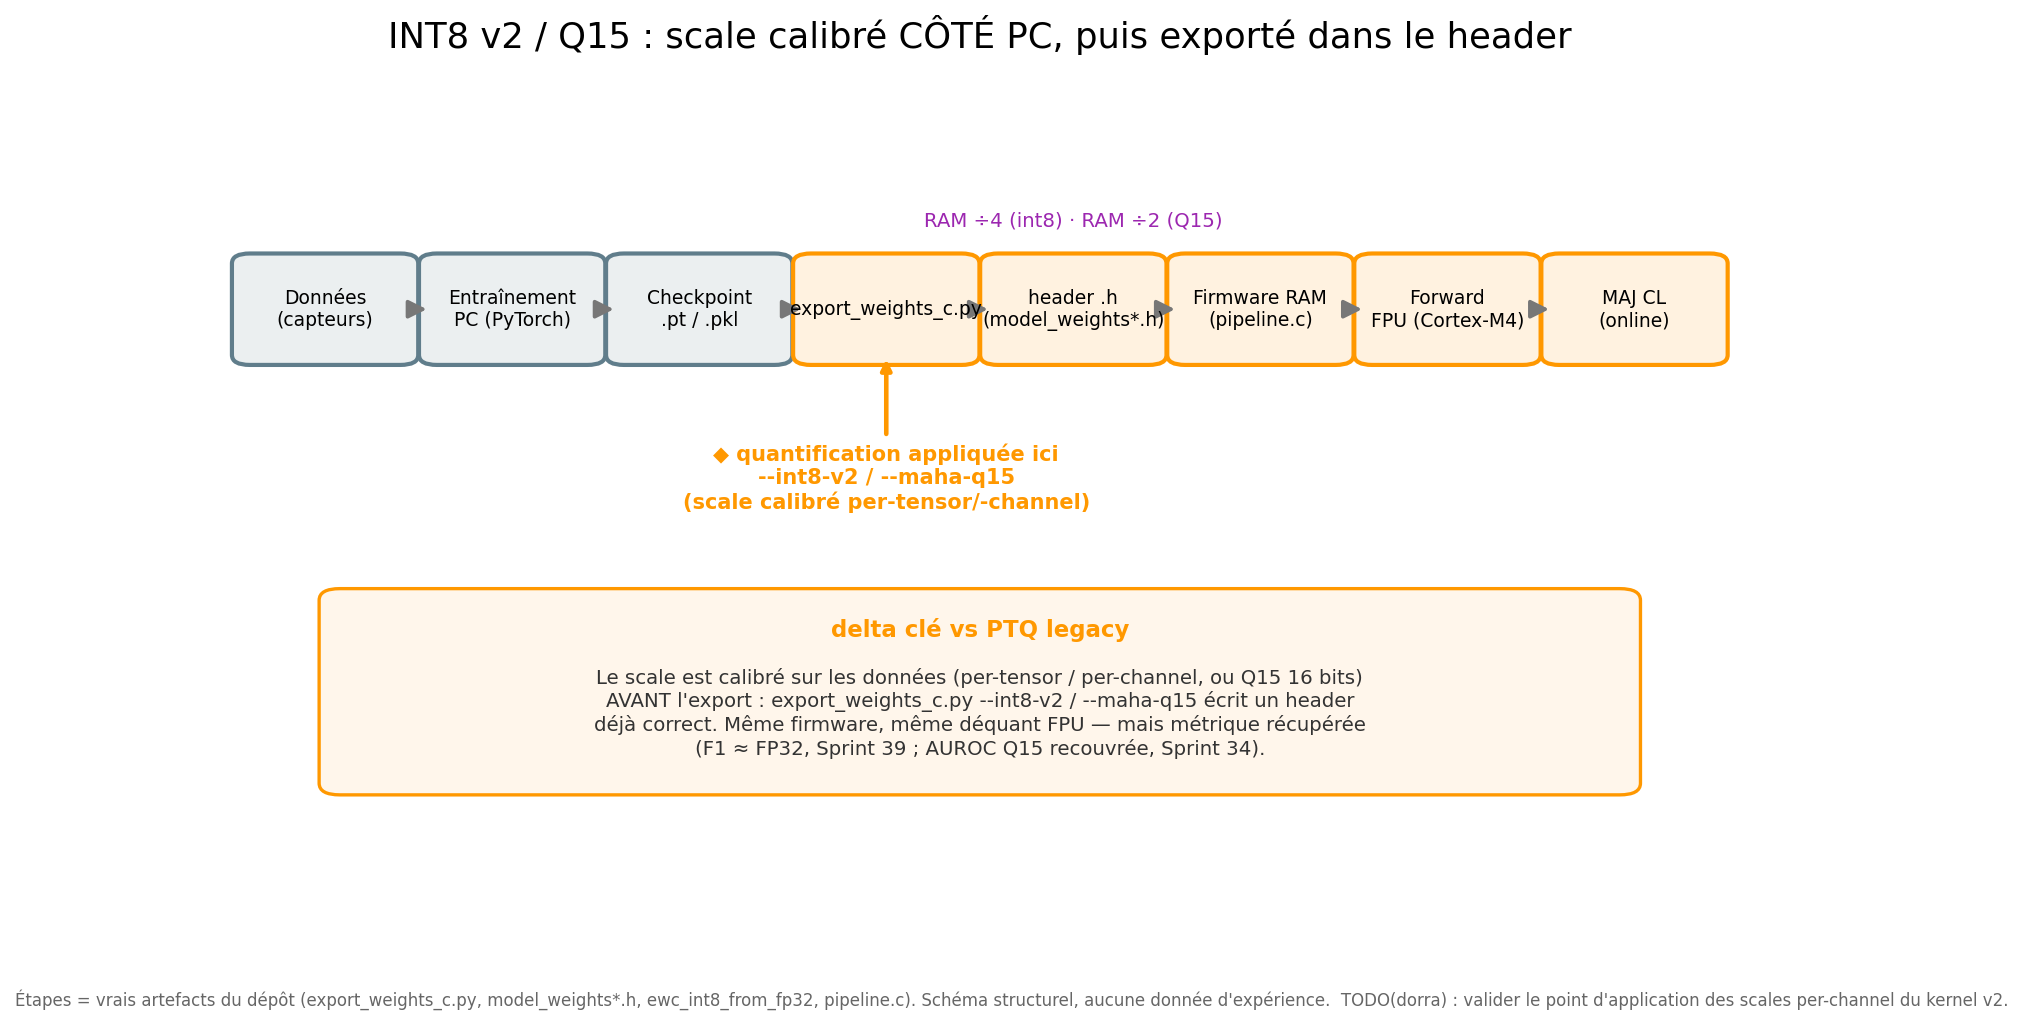

In [13]:
display(Image(str(FIG / "quantization/pipeline" / "pipeline_int8_v2_q15.png")))

## §4 — Impact mesuré : I2→I6

Chiffres **chargés depuis les JSON** d'expériences (aucune relance de campagne). Les valeurs susceptibles d'être re-mesurées (board v2) sont **affichées par cellule de code** ci-dessous, pas recopiées en dur.

### I2 — Ablation Sprint 39 : attribution de la perte de F1

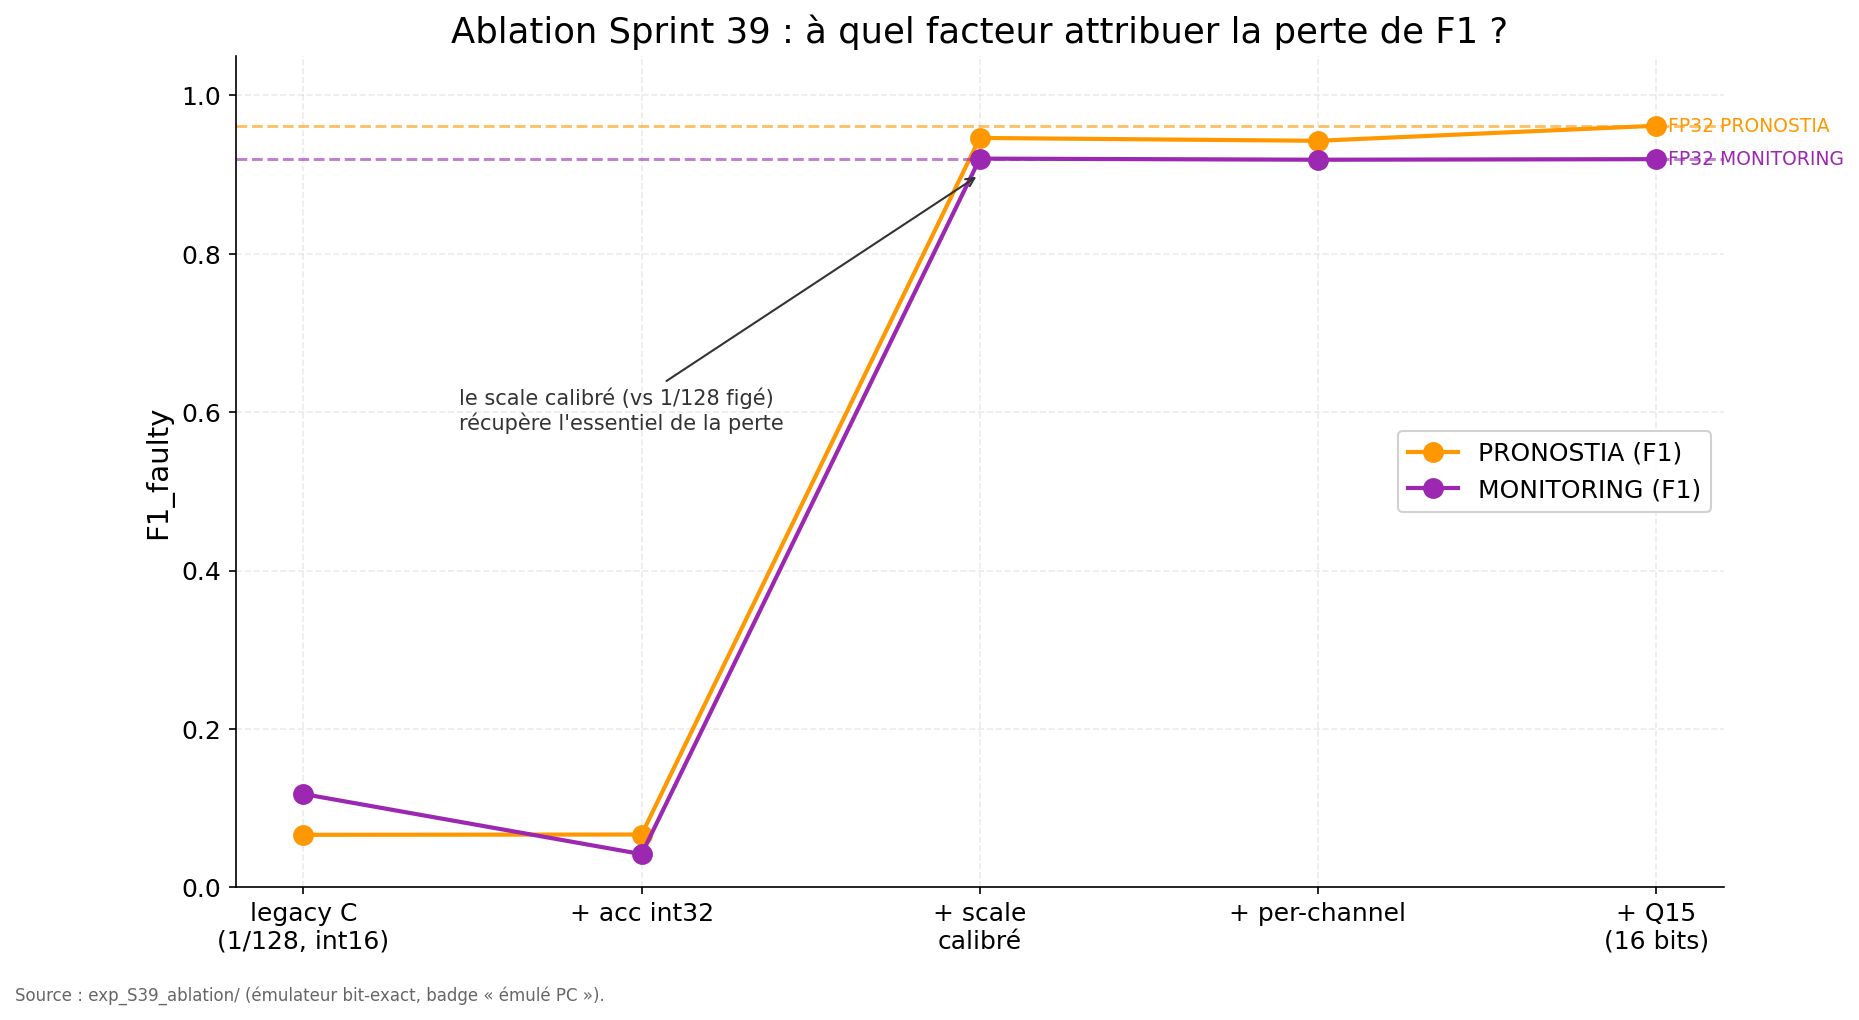

In [14]:
display(Image(str(FIG / "quantization/impact" / "ablation_perte_f1.png")))

In [15]:
from src.figures.catalogs.quant_impact import _ablation
for ds in ('pronostia', 'monitoring'):
    a = _ablation(ds)
    print(ds, '— FP32:', round(a['f1_fp32'], 4),
          '| legacy_c:', round(a['ladder']['legacy_c'], 4),
          '| per_tensor_calib:', round(a['ladder']['per_tensor_calib'], 4),
          '| q15:', round(a['ladder']['q15'], 4))

pronostia — FP32: 0.9616 | legacy_c: 0.0663 | per_tensor_calib: 0.9462 | q15: 0.9616
monitoring — FP32: 0.9194 | legacy_c: 0.1178 | per_tensor_calib: 0.9201 | q15: 0.9194


> **À dire** : le saut se produit à *+ scale calibré* — c'est la **calibration de l'échelle** (et non l'accumulateur int32, ni le per-channel, ni Q15) qui récupère l'essentiel de la perte.

### I3 — Récupération Q15 sur Mahalanobis

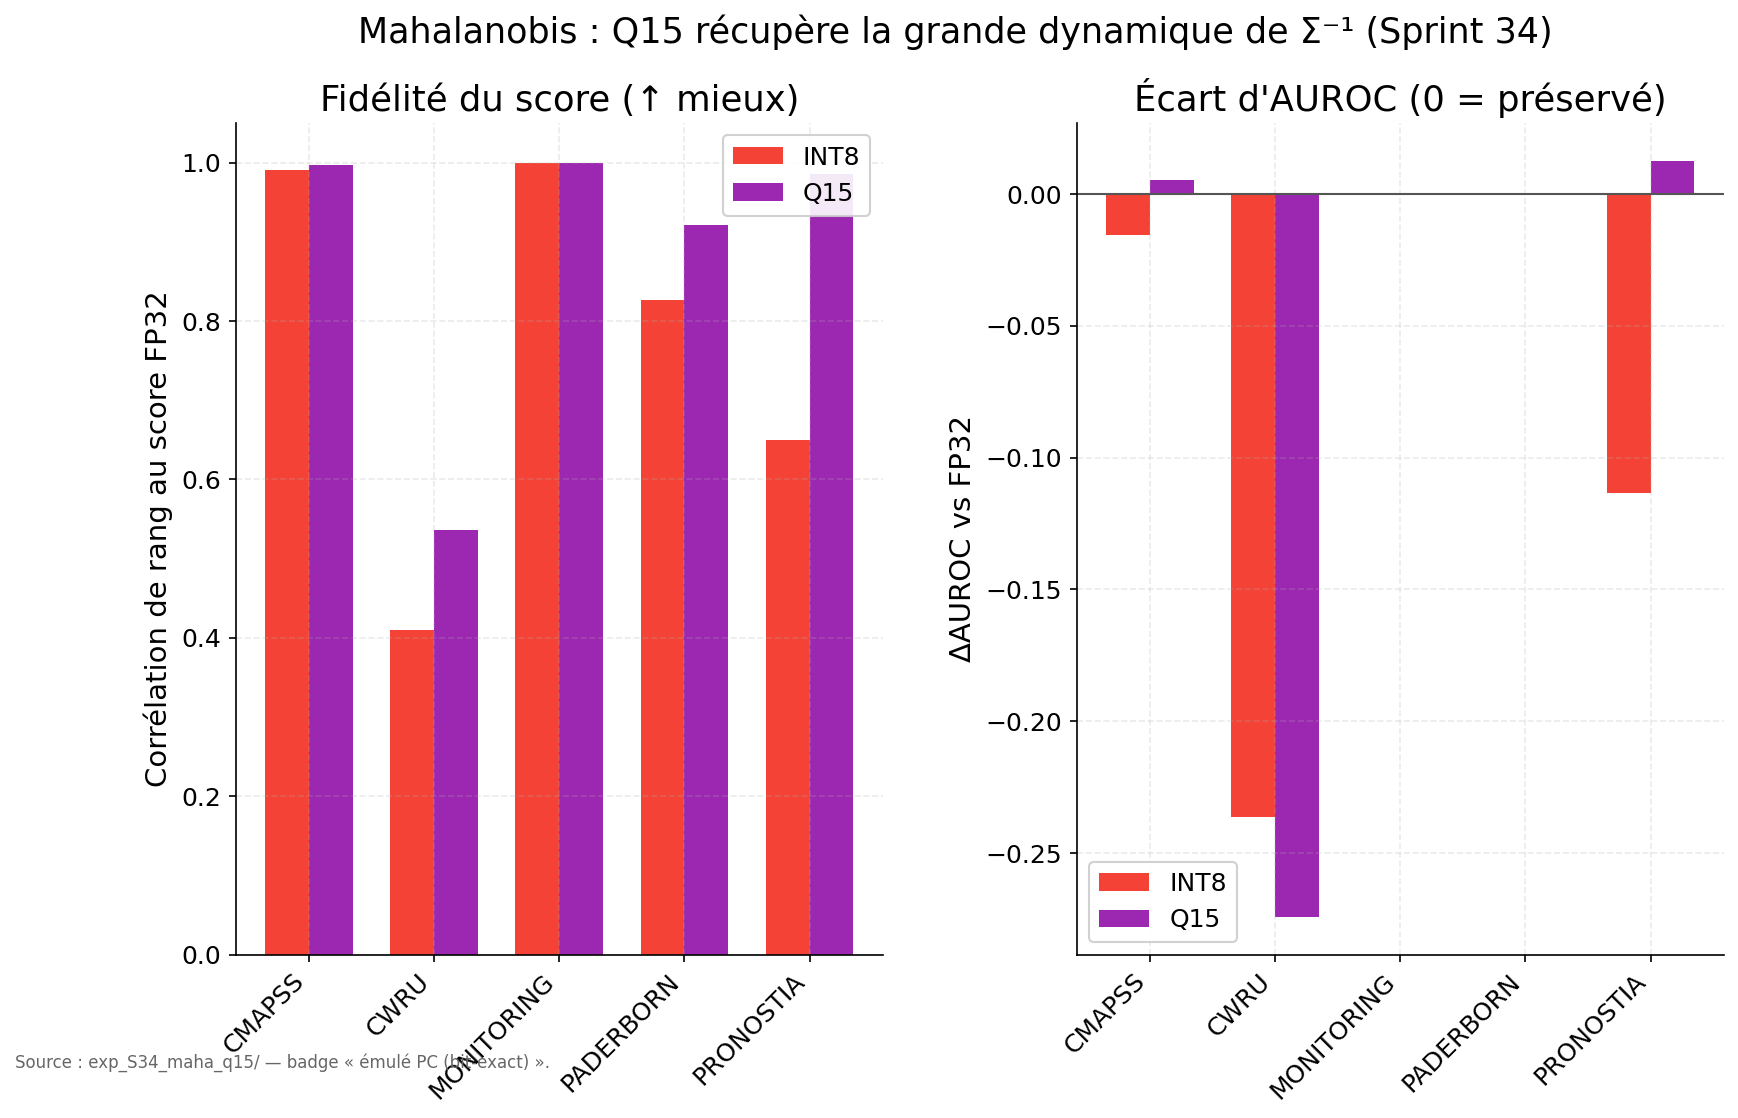

In [16]:
display(Image(str(FIG / "quantization/impact" / "recuperation_q15_maha.png")))

In [17]:
from src.figures.catalogs.quant_impact import _maha_variants, DATASETS
for ds in DATASETS:
    m = _maha_variants(ds)
    if m is None:
        continue
    print(ds, '— corr INT8:', round(m['int8']['corr'], 3),
          '| corr Q15:', round(m['q15']['corr'], 3))

cmapss — corr INT8: 0.991 | corr Q15: 0.996
cwru — corr INT8: 0.409 | corr Q15: 0.536
monitoring — corr INT8: 1.0 | corr Q15: 1.0
paderborn — corr INT8: 0.827 | corr Q15: 0.921
pronostia — corr INT8: 0.649 | corr Q15: 0.985


> **Nuance honnête** : sur CWRU, l'AUROC FP32 est déjà sub-aléatoire (binarisation dégénérée) — Q15 y reste dégradé, non par perte de fidélité mais parce que `mu_` reste INT8 (piste future Sprint 34).

### I4 — Gain RAM (Gap 3)

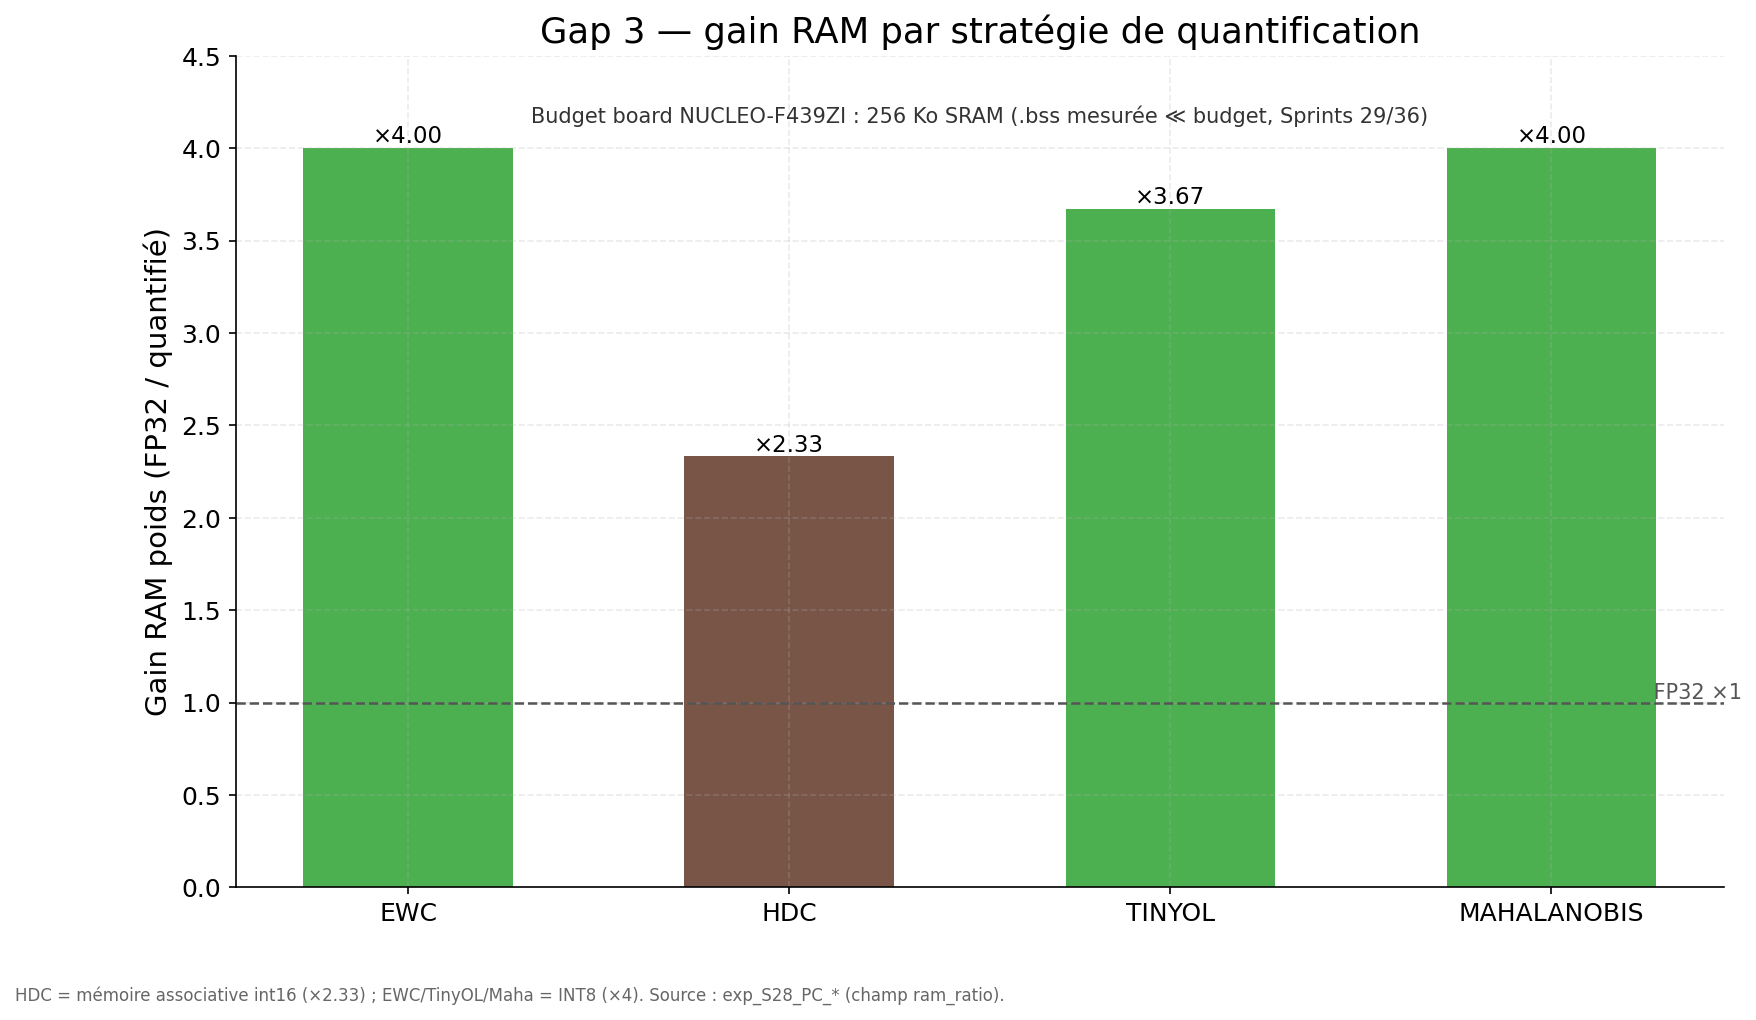

In [18]:
display(Image(str(FIG / "quantization/impact" / "ram_gap3.png")))

### I5 — Paradoxe latence board

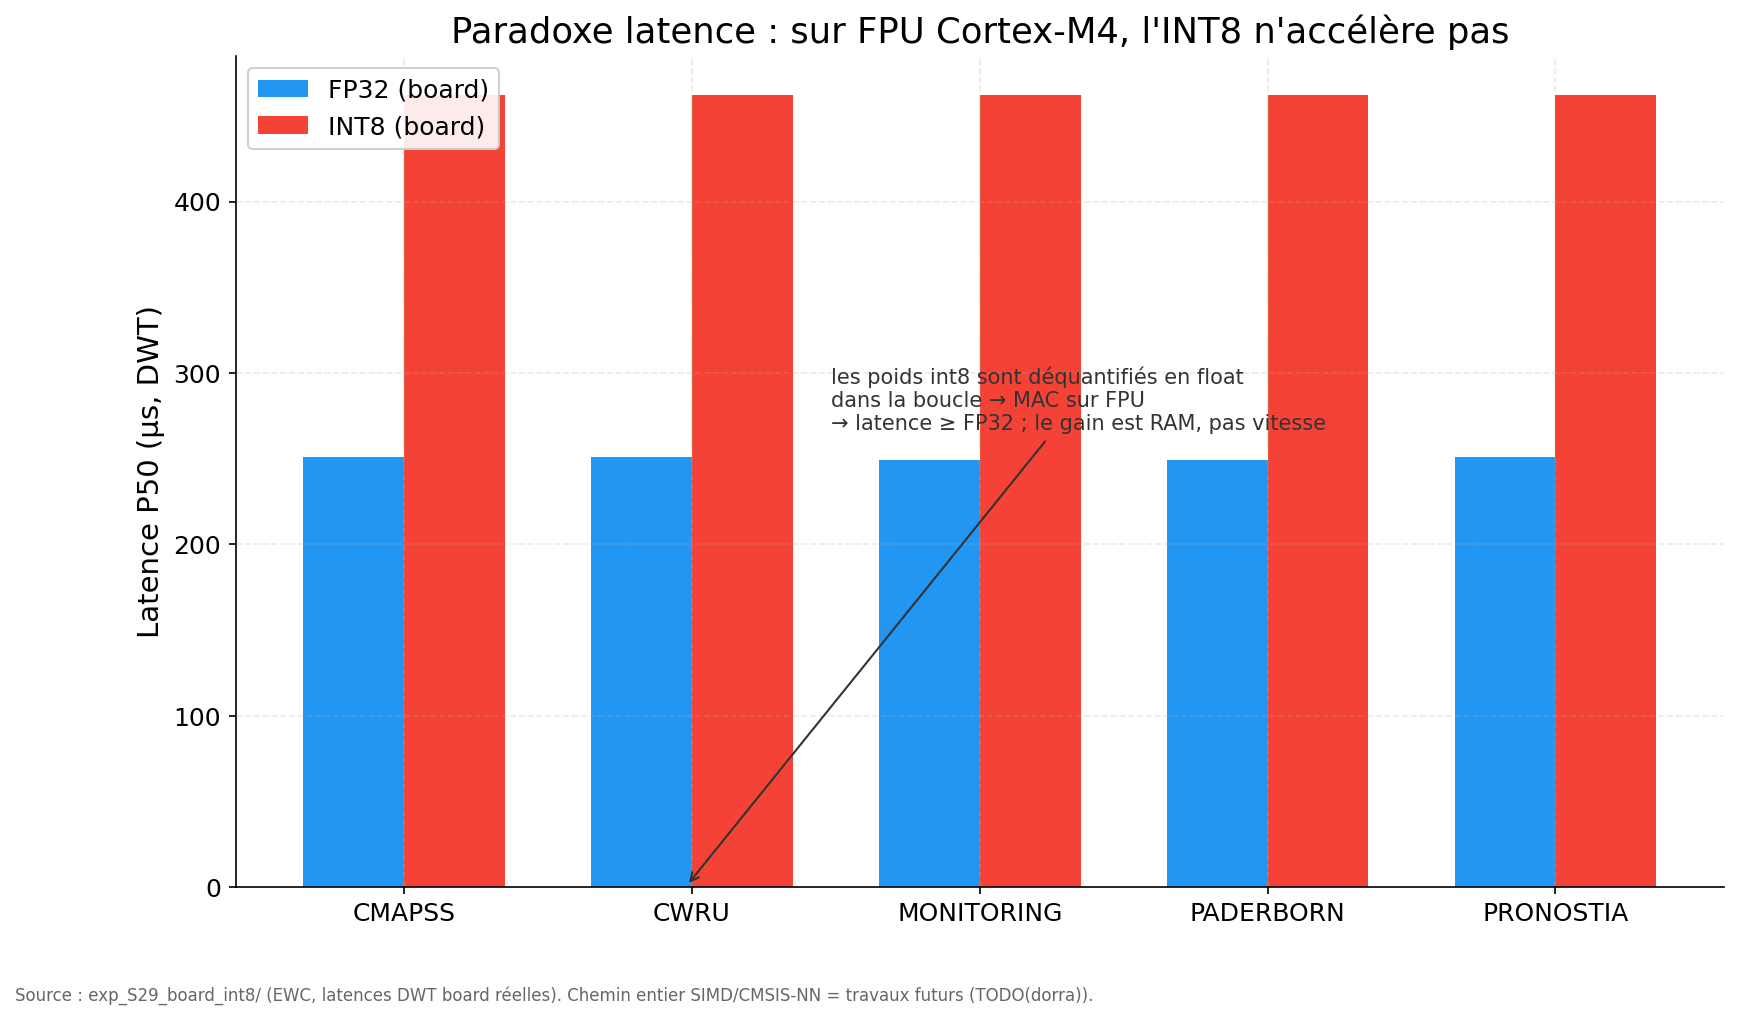

In [19]:
display(Image(str(FIG / "quantization/impact" / "paradoxe_latence.png")))

In [20]:
from src.figures.catalogs.quant_impact import _board_latency, DATASETS
for ds in DATASETS:
    fp, q = _board_latency(ds)
    if fp is None:
        continue
    print(ds, '— FP32:', fp, 'µs | INT8:', q, 'µs (ratio %.2f)' % (q / fp))

cmapss — FP32: 251.0 µs | INT8: 462.0 µs (ratio 1.84)
cwru — FP32: 251.0 µs | INT8: 462.0 µs (ratio 1.84)
monitoring — FP32: 249.0 µs | INT8: 462.0 µs (ratio 1.86)
paderborn — FP32: 249.0 µs | INT8: 462.0 µs (ratio 1.86)
pronostia — FP32: 251.0 µs | INT8: 462.0 µs (ratio 1.84)


### I6 — Même format INT8, résultats opposés (QAT vs PTQ vs v2)

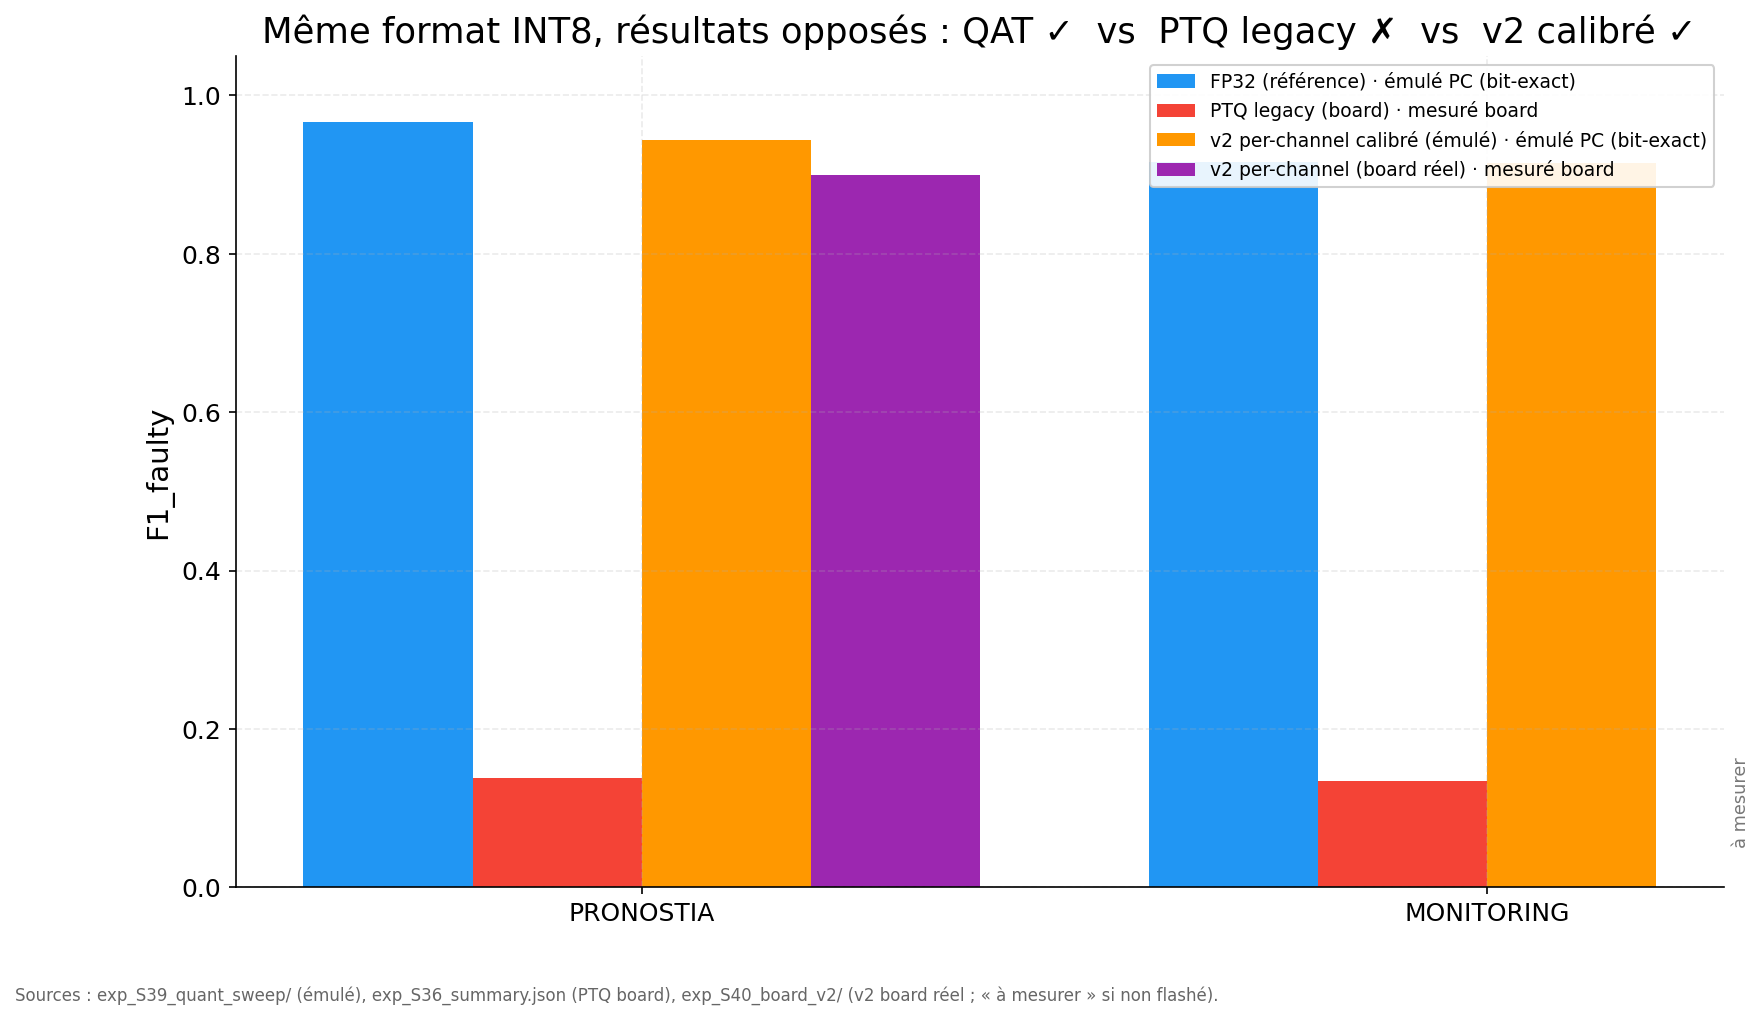

In [21]:
display(Image(str(FIG / "quantization/impact" / "qat_vs_ptq_resultats.png")))

In [22]:
from src.figures.catalogs.quant_impact import _board_v2_f1
# Valeur board réelle du kernel v2 (S40) — « à mesurer » si la cellule n'est pas flashée
for ds in ('pronostia', 'monitoring'):
    print(ds, '— v2 board (frozen) F1 :', _board_v2_f1(ds, 'frozen'))

pronostia — v2 board (frozen) F1 : 0.8995
monitoring — v2 board (frozen) F1 : à mesurer


## §5 — Limites & honnêteté

- **Plateformes** : chaque série des figures d'impact porte un badge — `PC natif` (S28), `émulé PC (bit-exact)` (émulateur S39), `mesuré board` (S29/S36/S40). Ils ne sont jamais mélangés sans distinction (règle Sprint 40).
- **Cellules non mesurées** : le board kernel v2 (S40) n'est flashé que pour Pronostia ; les autres cellules affichent **« à mesurer »** (jamais 0, jamais extrapolé). Relancer §0 après un nouveau flash S40 remplit automatiquement I6.
- **Paradoxe latence** (I5, P6) : sur FPU Cortex-M4, la déquantification dans la boucle rend l'INT8 *plus lent* que FP32 — le gain est **RAM uniquement**. Le chemin entier SIMD/CMSIS-NN reste un travail futur (`TODO(dorra)`).
- **`mu_` Q15** : sur très grande dynamique, l'erreur résiduelle vient de `mu_` encore INT8 — piste d'amélioration (Sprint 34).
- **Métriques nommées** : F1, AUROC, corrélation de rang — jamais d'« accuracy » fourre-tout (leçon Sprint 35 : accuracy trompeuse).